## **TABLE OF CONTENTS**

1. [Introduction](#Introduction)
2. [Exploratory Data Analysis](#ExploratoryDataAnalysis)
3. [Modeling](#Modeling)
   - [XGBoost](#XGBoost)
   - [ARIMA](#ARIMA)
      - [Customer segmentation Analysis](#Customer-segmentation-Analysis)
      - [ARIMA with the High Growth Customer Group](#ARIMA-with-the-High-Growth-Customer-Group)
   - [SVR](#SVR)
   - [Decision Trees](#Decision-Trees)

4. [RESULTS](#RESULTS)
5. [Group members and their contribution](#Group-members-and-their-contribution)

<a id='Introduction'></a>
# **INTRODUCTION**

##**Project Goal**
Identify and analyze customer group distribution and characteristics.
Evaluate order volumes and transition potential between low (White Trucks) and high (Red Trucks) volume groups.
Forecast future delivery volumes using the ARIMA model.
##**Business and Analytic Problems**
**Customer Concentration Analysis:** Determine regions have the highest concentration of customer groups.

**Customer Characteristics Analysis:** Identify key attributes  of customer groups.

**Order Volume Evaluation:** Assess the potential for low-volume customer groups (White Trucks) to increase orders and transition to higher volumes (Red Trucks).

**Forecasting Demand:** Predict future delivery volumes to support logistics and inventory planning.
##**Purpose of the Notebook**
**Customer Group Distribution:** Map and analyze customer groups by delivered volume and regions.

**Behavioral Insights**: Examine order history and trends by region.


**Forecasting with ARIMA:** Predict future order volumes for strategic decision-making.
##**Potential Target Variables & Important Features**
**Delivered Cases (Target):** Number of product cases delivered per order.

**Delivered Gallons (Target):** Volume of product delivered in gallons.

**Order Type:** Categorization of different order types.

**Frequent Order Type:** Most commonly ordered products or categories.

**Cold Drink Channel:** Distribution channel for cold drink products.

**Trade Channel:** Type of business or trade category (e.g., retail, wholesale).

**Zip Code:** Geographic region of the customer.


Models for Analysis & Forecasting

**XGBoost:** For predictive modeling and feature importance analysis.

**Segment Customers Based on Delivered Volume** Identify highgrowth customers and their characteristics

**ARIMA:** For time-series forecasting of delivery volumes.

**Support Vector Regression (SVR):** For capturing non-linear relationships in sales data.

**Decision Trees:** For understanding customer segmentation and order patterns.


<a id='ExploratoryDataAnalysis'></a>
# **EXPLORATORY DATA ANALYSIS (EDA)**

## **Explore the data**

#### Install and Load Necessary Packages

In [ ]:
# List files in the current directory
list.files()

[1] "customer_address_and_zip_mapping.csv"
 [2] "customer_profile.csv"                
 [3] "delivery_cost_data.xlsx"             
 [4] "High_Growth_Customers.csv"           
 [5] "merged_data_xgb.rds"                 
 [6] "merged_data.csv"                     
 [7] "sample_data"                         
 [8] "transactional_data.csv"              
 [9] "xgb_model_cases.rds"                 
[10] "xgb_model_gallons.rds"

In [ ]:
# Install necessary packages
install.packages("tidyverse")   # For data manipulation & visualization
install.packages("readr")       # For reading CSV files
install.packages("readxl")      # For reading Excel files
install.packages("skimr")       # For summary statistics
install.packages("janitor")     # For cleaning column names
install.packages("dplyr")       # For data manipulation
install.packages("corrr")
install.packages("ggcorrplot")
install.packages("car")
# install.packages("xgboost") #, type = "source"
#install.packages("caret")  #, dependencies = TRUE
#library(xgboost)
library(dplyr)
#library(caret)
# Load libraries
library(tidyverse)
library(readr)
library(readxl)
library(skimr)
library(janitor)
library(dplyr)
library(corrr)
library(ggcorrplot)
library(car)


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘snakecase’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘iterators’, ‘permute’, ‘ca’, ‘foreach’, ‘gclus’, ‘qap’, ‘registry’, ‘TSP’, ‘vegan’, ‘ggrepel’, ‘seriation’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘reshape2’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also instal

In [ ]:
# Define file paths from Google Drive
# old directory: /content/drive/MyDrive/MSBA-Capstone2025/Datasets/

customer_profile_path <- "customer_profile.csv"
transactional_data_path <- "transactional_data.csv"
delivery_cost_data_path <- "delivery_cost_data.xlsx"
customer_address_path <- "customer_address_and_zip_mapping.csv"

# Read CSV files
customer_profile <- read_csv(customer_profile_path)
transactional_data <- read_csv(transactional_data_path)
customer_address <- read_csv(customer_address_path)
delivery_cost_data <- read_csv(delivery_cost_data_path)

# Read Excel file
delivery_cost_data <- read_excel(delivery_cost_data_path)

Rows: 30478 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): FREQUENT_ORDER_TYPE, FIRST_DELIVERY_DATE, ON_BOARDING_DATE, COLD_DR...
dbl (3): CUSTOMER_NUMBER, PRIMARY_GROUP_NUMBER, ZIP_CODE
lgl (2): LOCAL_MARKET_PARTNER, CO2_CUSTOMER

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1045540 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): TRANSACTION_DATE, ORDER_TYPE
dbl (9): WEEK, YEAR, CUSTOMER_NUMBER, ORDERED_CASES, LOADED_CASES, DELIVERED...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1801 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): full address
dbl (1): 

In [ ]:
# Clean column names
customer_address <- clean_names(customer_address)
customer_profile <- clean_names(customer_profile)
transactional_data <- clean_names(transactional_data)
delivery_cost_data <- clean_names(delivery_cost_data)

* The clean_names() function from the janitor package standardizes column names in a dataframe by converting them to lowercase, replacing spaces and special characters with underscores, and ensuring they are unique. This makes data easier to work with, prevents errors caused by spaces or special characters, and improves consistency when merging datasets.

### **Check the Structure of the Datasets**

In [ ]:
# Check the structure of datasets (customer_address)
str(customer_address)

spc_tbl_ [1,801 × 2] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ zip         : num [1:1801] 71018 71021 71023 71024 71039 ...
 $ full_address: chr [1:1801] "71018,Cotton Valley,Louisiana,LA,Webster,119,32.819,-93.4259" "71021,Cullen,Louisiana,LA,Webster,119,32.9721,-93.4492" "71023,Doyline,Louisiana,LA,Webster,119,32.49,-93.3996" "71024,Dubberly,Louisiana,LA,Webster,119,32.5192,-93.2142" ...
 - attr(*, "spec")=
  .. cols(
  ..   zip = col_double(),
  ..   `full address` = col_character()
  .. )
 - attr(*, "problems")=<externalptr> 


* Converting zip codes to character format ensures accurate handling and preserves leading zeros, crucial for matching and referencing in various data processing tasks.

In [ ]:
# Check the structure of datasets (customer_profile)
str(customer_profile)

spc_tbl_ [30,478 × 11] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ customer_number     : num [1:30478] 5.02e+08 5.01e+08 6.00e+08 5.01e+08 6.00e+08 ...
 $ primary_group_number: num [1:30478] 376 NA 2158 2183 1892 ...
 $ frequent_order_type : chr [1:30478] "MYCOKE LEGACY" "SALES REP" "SALES REP" "OTHER" ...
 $ first_delivery_date : chr [1:30478] "1/2/2024" "4/14/2022" "3/4/2016" "2/6/2019" ...
 $ on_boarding_date    : chr [1:30478] "8/28/2023" "3/22/2022" "3/22/2012" "11/23/2018" ...
 $ cold_drink_channel  : chr [1:30478] "DINING" "DINING" "DINING" "DINING" ...
 $ trade_channel       : chr [1:30478] "FAST CASUAL DINING" "COMPREHENSIVE DINING" "FAST CASUAL DINING" "FAST CASUAL DINING" ...
 $ sub_trade_channel   : chr [1:30478] "PIZZA FAST FOOD" "FSR - MISC" "OTHER FAST FOOD" "ASIAN FAST FOOD" ...
 $ local_market_partner: logi [1:30478] TRUE TRUE TRUE FALSE TRUE TRUE ...
 $ co2_customer        : logi [1:30478] FALSE TRUE FALSE FALSE FALSE TRUE ...
 $ zip_code            : num [1:30478] 216

* Since customer_number is unique identifier for each outlet/store should be character (not numeric) to avoid misinterpretation.
* first_delivery_date and on_boarding_date are stored as characters, but they should be converted to Date format.

In [ ]:
# Check the structure of datasets(transactional_data)
str(transactional_data)

spc_tbl_ [1,045,540 × 11] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ transaction_date : chr [1:1045540] "1/5/2023" "1/6/2023" "1/9/2023" "1/11/2023" ...
 $ week             : num [1:1045540] 1 1 2 2 3 4 4 4 4 5 ...
 $ year             : num [1:1045540] 2023 2023 2023 2023 2023 ...
 $ customer_number  : num [1:1045540] 5.01e+08 5.00e+08 5.01e+08 6.01e+08 5.01e+08 ...
 $ order_type       : chr [1:1045540] "MYCOKE LEGACY" "MYCOKE LEGACY" "MYCOKE LEGACY" "SALES REP" ...
 $ ordered_cases    : num [1:1045540] 1 12.5 2 18 29 1.5 6 0 4 18 ...
 $ loaded_cases     : num [1:1045540] 1 12.5 2 16 29 1.5 5 0 1 17 ...
 $ delivered_cases  : num [1:1045540] 1 12.5 2 16 29 1.5 5 0 1 17 ...
 $ ordered_gallons  : num [1:1045540] 90 0 0 2.5 0 0 0 25 0 0 ...
 $ loaded_gallons   : num [1:1045540] 90 0 0 2.5 0 0 0 25 0 0 ...
 $ delivered_gallons: num [1:1045540] 90 0 0 2.5 0 0 0 25 0 0 ...
 - attr(*, "spec")=
  .. cols(
  ..   TRANSACTION_DATE = col_character(),
  ..   WEEK = col_double(),
  ..   YEAR = col_d

- transaction_date is stored as character, but it should be converted to Date format.

In [ ]:
# Check the structure of datasets (delivery_cost_data)
str(delivery_cost_data)

tibble [160 × 5] (S3: tbl_df/tbl/data.frame)
 $ cold_drink_channel  : chr [1:160] "WORKPLACE" "WORKPLACE" "WORKPLACE" "WORKPLACE" ...
 $ vol_range           : chr [1:160] "0 - 149" "150 - 299" "300 - 449" "450 - 599" ...
 $ applicable_to       : chr [1:160] "Bottles and Cans" "Bottles and Cans" "Bottles and Cans" "Bottles and Cans" ...
 $ median_delivery_cost: num [1:160] 8.06 4.17 2.99 2.52 2.06 ...
 $ cost_type           : chr [1:160] "Per Case" "Per Case" "Per Case" "Per Case" ...


#### Convert Data Types

This code updates the customer_profile and transactional_data datasets by converting certain text fields to date format and ensuring customer_number (customer identifiers) and zip code are treated as text to maintain formatting accuracy.

In [ ]:
# Convert first_delivery_date and on_boarding_date from character strings to date format
customer_profile <- customer_profile %>%
  mutate(
    first_delivery_date = as.Date(first_delivery_date, format="%m/%d/%Y"),
    on_boarding_date = as.Date(on_boarding_date, format="%m/%d/%Y")
  )

# Convert transaction_date from character string to date format and customer_number from numeric to character
transactional_data <- transactional_data %>%
  mutate(
    transaction_date = as.Date(transaction_date, format="%m/%d/%Y"),
    customer_number = as.character(customer_number)
  )

  # Convert zip code from numeric to character
customer_address <- customer_address %>%
  mutate(zip = as.character(zip))


Next we want to check for missing values within the dataset and possible outliers that could possibly skew our analysis and modeling.

In [ ]:
# Get a summary of missing values
map(list(customer_address, customer_profile, transactional_data, delivery_cost_data),
    ~ summarise_all(., ~ sum(is.na(.))))

[[1]]
# A tibble: 1 × 2
    zip full_address
  <int>        <int>
1     0            0

[[2]]
# A tibble: 1 × 11
  customer_number primary_group_number frequent_order_type first_delivery_date
            <int>                <int>               <int>               <int>
1               0                18196                   0                   0
# ℹ 7 more variables: on_boarding_date <int>, cold_drink_channel <int>,
#   trade_channel <int>, sub_trade_channel <int>, local_market_partner <int>,
#   co2_customer <int>, zip_code <int>

[[3]]
# A tibble: 1 × 11
  transaction_date  week  year customer_number order_type ordered_cases
             <int> <int> <int>           <int>      <int>         <int>
1                0     0     0               0          0             0
# ℹ 5 more variables: loaded_cases <int>, delivered_cases <int>,
#   ordered_gallons <int>, loaded_gallons <int>, delivered_gallons <int>

[[4]]
# A tibble: 1 × 5
  cold_drink_channel vol_range applicable_to median_delivery_cost cost_type
               <int>     <int>         <int>                <int>     <int>
1                  0         0             0                    0         0

Warning message:
“Removed 18196 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


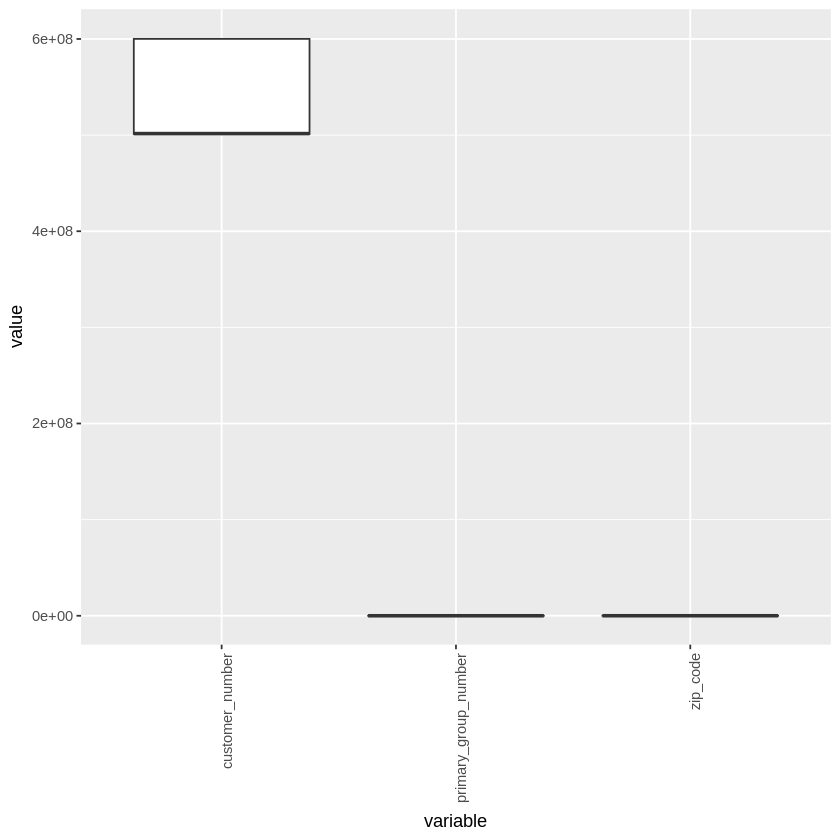

In [ ]:
# Boxplot to visualize outliers
customer_profile %>%
  select_if(is.numeric) %>%
  gather(key = "variable", value = "value") %>%
  ggplot(aes(x = variable, y = value)) +
  geom_boxplot() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))

In [ ]:
# Z-score method to flag outliers
detect_outliers <- function(df, threshold = 3) {
  df %>%
    select_if(is.numeric) %>%
    map_df(~ abs(scale(.)) > threshold) %>%
    bind_cols(df, .) # Add outlier flags to the original dataset
}

outliers_profile <- detect_outliers(customer_profile)

New names:
• `customer_number` -> `customer_number...1`
• `primary_group_number` -> `primary_group_number...2`
• `zip_code` -> `zip_code...11`
• `customer_number` -> `customer_number...12`
• `primary_group_number` -> `primary_group_number...13`
• `zip_code` -> `zip_code...14`


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_bar()`).”


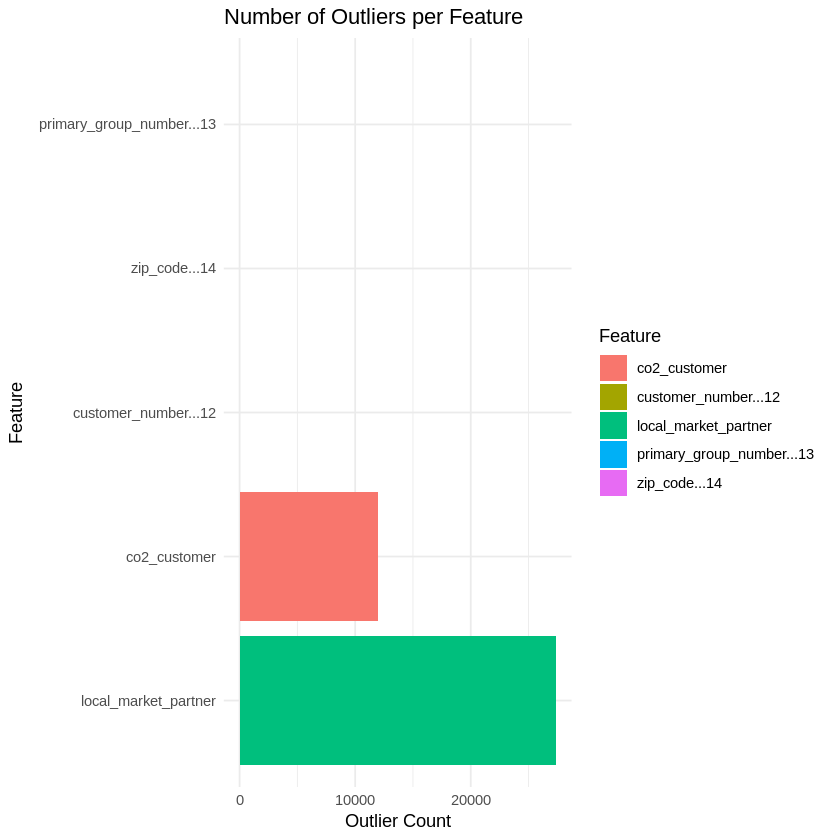

In [ ]:

# Histogram of outlier counts per feature
outliers_profile %>%
  select_if(is.logical) %>%
  summarise_all(sum) %>%
  pivot_longer(cols = everything(), names_to = "Feature", values_to = "Outlier_Count") %>%
  ggplot(aes(x = reorder(Feature, -Outlier_Count), y = Outlier_Count, fill = Feature)) +
  geom_bar(stat = "identity") +
  coord_flip() +
  labs(title = "Number of Outliers per Feature", x = "Feature", y = "Outlier Count") +
  theme_minimal()


#### View Summary Statistics

In [ ]:
# Summary statistics of each dataset (customer_address)
summary(customer_address)

     zip            full_address      
 Length:1801        Length:1801       
 Class :character   Class :character  
 Mode  :character   Mode  :character  

In [ ]:
# Summary statistics of each dataset (customer_profile)
summary(customer_profile)

 customer_number     primary_group_number frequent_order_type
 Min.   :500245678   Min.   :   4         Length:30478       
 1st Qu.:501164306   1st Qu.: 444         Class :character   
 Median :501573994   Median :1892         Mode  :character   
 Mean   :538301801   Mean   :2780                            
 3rd Qu.:600075795   3rd Qu.:4488                            
 Max.   :600975408   Max.   :9999                            
                     NA's   :18196                           
 first_delivery_date  on_boarding_date     cold_drink_channel
 Min.   :2015-11-28   Min.   :1981-08-01   Length:30478      
 1st Qu.:2017-08-30   1st Qu.:2012-10-22   Class :character  
 Median :2019-03-27   Median :2018-12-03   Mode  :character  
 Mean   :2020-01-30   Mean   :2016-03-02                     
 3rd Qu.:2022-10-27   3rd Qu.:2022-08-08                     
 Max.   :2024-12-31   Max.   :2024-12-23                     
                                                             
 trade_c

* primary_group_number has 18,196 missing values. This likely indicate that those store outlets do not belong to a specific retailer (chain) and are independent businesses.

* local_market_partner and co2_customers are logical variables (True/False)  with a significant majority being local market partners (27448 true vs. 3214 false). In contrast, less than half are CO2 customers (12033 true vs. 18629 false)

In [ ]:
# how many outlets each retailer has?
outlet_counts <- customer_profile %>%
  group_by(primary_group_number) %>%
  summarise(total_outlets = n()) %>%
  arrange(desc(total_outlets))

# View top retailers with most outlets
head(outlet_counts)


primary_group_number,total_outlets
<dbl>,<int>
NA,18196
437,670
2487,616
340,558
1194,365
2183,307


* The largest retailers groups are 437, 2487 and 340.



In [ ]:
# Check for duplicate customer numbers
duplicate_check <- customer_profile %>%
  group_by(customer_number) %>%
  summarise(unique_retailers = n_distinct(primary_group_number)) %>%
  filter(unique_retailers > 1)

# View duplicate cases
head(duplicate_check)


customer_number,unique_retailers
<dbl>,<int>


* The duplicate_check output shows no customer appears under multiple retailers (0 rows returned). This means each customer_number is uniquely assigned to one primary_group_number.

In [ ]:
# Summary statistics of each dataset (transactional_data)
summary(transactional_data)

 transaction_date          week            year      customer_number   
 Min.   :2023-01-01   Min.   : 1.00   Min.   :2023   Length:1045540    
 1st Qu.:2023-06-30   1st Qu.:14.00   1st Qu.:2023   Class :character  
 Median :2023-12-27   Median :26.00   Median :2023   Mode  :character  
 Mean   :2023-12-27   Mean   :26.23   Mean   :2023                     
 3rd Qu.:2024-06-25   3rd Qu.:38.00   3rd Qu.:2024                     
 Max.   :2024-12-31   Max.   :52.00   Max.   :2024                     
  order_type        ordered_cases      loaded_cases     delivered_cases   
 Length:1045540     Min.   :   0.00   Min.   :   0.00   Min.   :-3132.00  
 Class :character   1st Qu.:   0.00   1st Qu.:   0.00   1st Qu.:    0.00  
 Mode  :character   Median :   7.00   Median :   7.00   Median :    6.00  
                    Mean   :  26.85   Mean   :  25.92   Mean   :   25.13  
                    3rd Qu.:  18.50   3rd Qu.:  18.00   3rd Qu.:   17.33  
                    Max.   :8479.89   Max.   :

*  The first quartile for both cases and gallons contains a significant number of zeros, indicating that at least 25% of the entries report no cases or gallons being ordered, loaded, or delivered. This may be due to customers purchasing exclusively cases (bottles and cans) or gallons on specific days.

* The transactions span from January 1, 2023, to December 31, 2024, covering two full years which is ideal for analyzing seasonal trends and yearly performance.

* The presence of negative values in delivered_cases and delivered_gallons indicates possible returns or cancellations.

* The very high maximum values in ordered, loaded, and delivered cases and gallons suggest some exceptionally large transactions, which could be outliers or indicate bulk transactions by major customers.

* The mean values being higher than the medians in case and gallon metrics suggest a right-skewed distribution, meaning most transactions are small, but there are a few very large transactions.

In [ ]:
# Create a copy of the transactional_data dataframe
transactional_data_copy <- transactional_data

# Add combined volume columns to the copied dataframe
transactional_data_copy$ordered_total_volume = transactional_data_copy$ordered_cases + transactional_data_copy$ordered_gallons
transactional_data_copy$loaded_total_volume = transactional_data_copy$loaded_cases + transactional_data_copy$loaded_gallons
transactional_data_copy$delivered_total_volume = transactional_data_copy$delivered_cases + transactional_data_copy$delivered_gallons

# Calculate the summary statistics for the new combined volume columns
summary(transactional_data_copy$ordered_total_volume)
summary(transactional_data_copy$loaded_total_volume)
summary(transactional_data_copy$delivered_total_volume)


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
   0.000    8.547   15.500   36.725   30.000 8479.888 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    8.00   15.00   35.53   29.00 8171.56 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-3132.00     7.50    15.00    34.34    28.00  8069.48 

* The first quartile values are low across all categories (ordered: 8.756, loaded: 8.00, delivered: 7.50), which suggests that at least 25% of the transactions involve relatively small volumes.

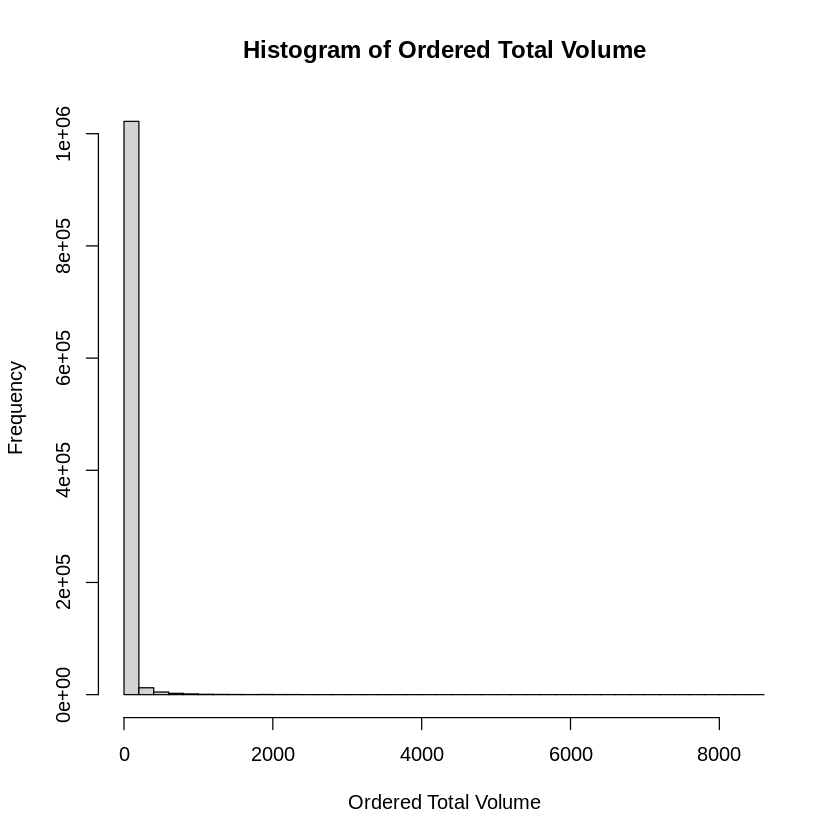

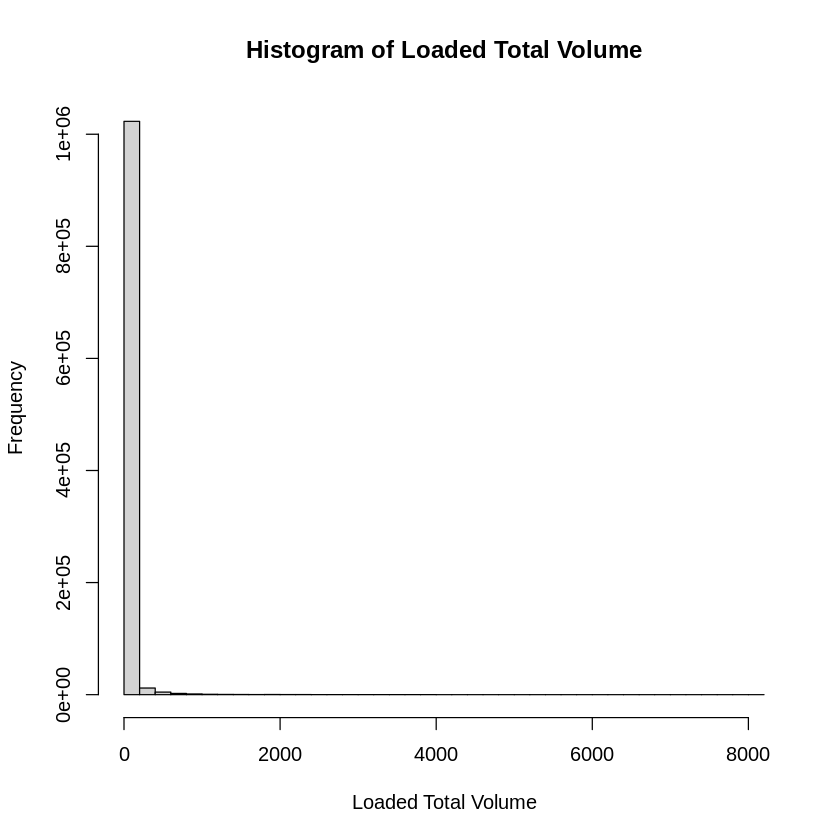

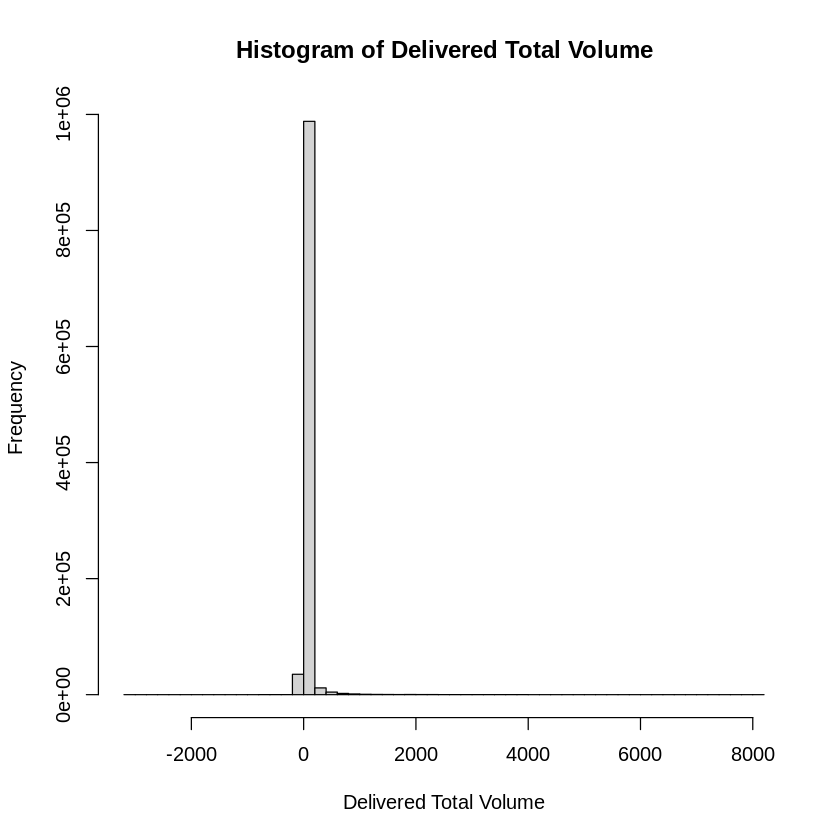

In [ ]:
# Histograms of combined volumes
hist(transactional_data_copy$ordered_total_volume, breaks=50, main="Histogram of Ordered Total Volume", xlab="Ordered Total Volume")
hist(transactional_data_copy$loaded_total_volume, breaks=50, main="Histogram of Loaded Total Volume", xlab="Loaded Total Volume")
hist(transactional_data_copy$delivered_total_volume, breaks=50, main="Histogram of Delivered Total Volume", xlab="Delivered Total Volume")


* The histograms show a heavy skew towards lower volumes with a few extreme outliers, as evidenced by the maximum values (ordered: 8479.888, loaded: 8171.56, delivered: 8069.48). These outliers may represent bulk transactions

In [ ]:
# Count occurrences of negative values
negative_cases <- transactional_data %>%
  filter(delivered_cases < 0 | delivered_gallons < 0) %>%
  summarise(count_negative = n())

print(negative_cases)


# A tibble: 1 × 1
  count_negative
           <int>
1           4221


* 4,221 transactions where either delivered_cases or delivered_gallons have negative values, indicate possible returns or cancellations.

In [ ]:
# Summary statistics of each dataset (delivery_cost_data)
summary(delivery_cost_data)

 cold_drink_channel  vol_range         applicable_to      median_delivery_cost
 Length:160         Length:160         Length:160         Min.   :0.3717      
 Class :character   Class :character   Class :character   1st Qu.:1.3255      
 Mode  :character   Mode  :character   Mode  :character   Median :2.2353      
                                                          Mean   :2.5972      
                                                          3rd Qu.:3.4730      
                                                          Max.   :8.5855      
  cost_type        
 Length:160        
 Class :character  
 Mode  :character  
                   
                   
                   

* Delivery costs vary significately, from as low as 0.37 to as high as 8.59 dollars per unit.

#### View Sample Data

In [ ]:
# Display first 5 rows (customer_address)
head(customer_address, 5)

zip,full_address
<chr>,<chr>
71018,"71018,Cotton Valley,Louisiana,LA,Webster,119,32.819,-93.4259"
71021,"71021,Cullen,Louisiana,LA,Webster,119,32.9721,-93.4492"
71023,"71023,Doyline,Louisiana,LA,Webster,119,32.49,-93.3996"
71024,"71024,Dubberly,Louisiana,LA,Webster,119,32.5192,-93.2142"
71039,"71039,Heflin,Louisiana,LA,Webster,119,32.447,-93.2852"


In [ ]:
# Display first 5 rows (customer_profile)
head(customer_profile, 5)

customer_number,primary_group_number,frequent_order_type,first_delivery_date,on_boarding_date,cold_drink_channel,trade_channel,sub_trade_channel,local_market_partner,co2_customer,zip_code
<dbl>,<dbl>,<chr>,<date>,<date>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<dbl>
501556470,376,MYCOKE LEGACY,2024-01-02,2023-08-28,DINING,FAST CASUAL DINING,PIZZA FAST FOOD,TRUE,FALSE,21664
501363456,NA,SALES REP,2022-04-14,2022-03-22,DINING,COMPREHENSIVE DINING,FSR - MISC,TRUE,TRUE,1885
600075150,2158,SALES REP,2016-03-04,2012-03-22,DINING,FAST CASUAL DINING,OTHER FAST FOOD,TRUE,FALSE,67073
500823056,2183,OTHER,2019-02-06,2018-11-23,DINING,FAST CASUAL DINING,ASIAN FAST FOOD,FALSE,FALSE,1885
600082383,1892,SALES REP,2016-03-04,2010-08-31,PUBLIC SECTOR,PUBLIC SECTOR (NON-MILITARY),OTHER PUBLIC SECTOR,TRUE,FALSE,1203


In [ ]:
# Display first 5 rows (transactional_data)
head(transactional_data, 5)

transaction_date,week,year,customer_number,order_type,ordered_cases,loaded_cases,delivered_cases,ordered_gallons,loaded_gallons,delivered_gallons
<date>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023-01-05,1,2023,501202893,MYCOKE LEGACY,1.0,1.0,1.0,90.0,90.0,90.0
2023-01-06,1,2023,500264574,MYCOKE LEGACY,12.5,12.5,12.5,0.0,0.0,0.0
2023-01-09,2,2023,501174701,MYCOKE LEGACY,2.0,2.0,2.0,0.0,0.0,0.0
2023-01-11,2,2023,600586532,SALES REP,18.0,16.0,16.0,2.5,2.5,2.5
2023-01-17,3,2023,501014325,SALES REP,29.0,29.0,29.0,0.0,0.0,0.0


In [ ]:
# Display first 5 rows (delivery_cost_data)
head(delivery_cost_data, 5)

cold_drink_channel,vol_range,applicable_to,median_delivery_cost,cost_type
<chr>,<chr>,<chr>,<dbl>,<chr>
WORKPLACE,0 - 149,Bottles and Cans,8.064950,Per Case
WORKPLACE,150 - 299,Bottles and Cans,4.165646,Per Case
WORKPLACE,300 - 449,Bottles and Cans,2.991558,Per Case
WORKPLACE,450 - 599,Bottles and Cans,2.524222,Per Case
WORKPLACE,600 - 749,Bottles and Cans,2.056886,Per Case


#### View column names

In [ ]:
# Display column names (customer_address)
print(colnames(customer_address))

[1] "zip"          "full_address"


In [ ]:
# Display column names (customer_profile)
print(colnames(customer_profile))

 [1] "customer_number"      "primary_group_number" "frequent_order_type" 
 [4] "first_delivery_date"  "on_boarding_date"     "cold_drink_channel"  
 [7] "trade_channel"        "sub_trade_channel"    "local_market_partner"
[10] "co2_customer"         "zip_code"            


In [ ]:
# Display column names (transactional_data)
print(colnames(transactional_data))

 [1] "transaction_date"  "week"              "year"             
 [4] "customer_number"   "order_type"        "ordered_cases"    
 [7] "loaded_cases"      "delivered_cases"   "ordered_gallons"  
[10] "loaded_gallons"    "delivered_gallons"


In [ ]:
# Display column names (delivery_cost_data)
print(colnames(delivery_cost_data))

[1] "cold_drink_channel"   "vol_range"            "applicable_to"       
[4] "median_delivery_cost" "cost_type"           


### **Correlation and Multicollinearity**




**Primary Focus on Transactional Data:**
Since it contains numeric variables, we can analyze correlations between order size, delivery, and volume.

**Potential Joins for Deeper Analysis:**
Join transactional_data with customer_profile (on CUSTOMER_NUMBER) to see if trade channel affects order size.
Merge delivery_cost_data based on trade channels to check cost relationships.

#### Transactional Data


In [ ]:
# Install necessary libraries
if(!require(corrr)) install.packages("corrr") # Install corrr if not already installed
if(!require(ggcorrplot)) install.packages("ggcorrplot") # Install ggcorrplot if not already installed
if(!require(car)) install.packages("car") # Install car if not already installed

# Load necessary libraries
library(tidyverse)
library(readr)
library(readxl)
library(skimr)
library(janitor)
library(dplyr)
library(corrr)
library(ggcorrplot)
library(car)

Loading required package: corrr

Loading required package: ggcorrplot

Loading required package: ggplot2

Loading required package: car

Loading required package: carData

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ lubridate 1.9.4     ✔ tibble    3.2.1
✔ purrr     1.0.4     ✔ tidyr     1.3.1
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::recode() masks car::recode()
✖ purrr::some()   masks car::some()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘skimr’


The following object is masked from ‘package:corrr’:

    focus



Attaching package: ‘janitor’


The following objects are masked from ‘package:stats’:

    chisq.test, fisher.test




In [ ]:
# Select only numeric columns for correlation analysis
numeric_cols <- transactional_data %>%
  select(where(is.numeric))

# Compute correlation matrix
cor_matrix <- cor(numeric_cols, use = "pairwise.complete.obs")

# Visualize correlation matrix
ggcorrplot(cor_matrix, method = "circle", type = "lower",
           lab = TRUE, lab_size = 3, title = "Correlation Matrix for Transactional Data")

ERROR: Error: object 'transactional_data' not found


**Key Observations**

- ORDERED_CASES, LOADED_CASES, and DELIVERED_CASES are highly correlated (0.99 or more). This suggests that the number of ordered cases closely matches loaded and delivered cases.

- ORDERED_GALLONS, LOADED_GALLONS, and DELIVERED_GALLONS also show strong correlations (0.97 - 0.98), meaning liquid volume follows a similar trend.

- WEEK, YEAR, and CUSTOMER_NUMBER have very weak correlations with order quantities, meaning time and customer IDs don't significantly impact order volume in a simple linear sense.

**Conclusion:** Some variables are redundant (e.g., ORDERED_CASES and LOADED_CASES).


#### Multicollinearity Check (VIF)

In [ ]:
# Define a linear model for VIF calculation (Choose a dependent variable if relevant)
lm_model <- lm(delivered_cases ~ ., data = numeric_cols)  # Replace with relevant dependent variable

# Compute VIF values
vif_values <- vif(lm_model)

# Print VIF values
print(vif_values)

ERROR: Error in eval(mf, parent.frame()): object 'numeric_cols' not found


VIF Interpretation:
- VIF < 5 → Low multicollinearity (good).
- VIF 5-10 → Moderate multicollinearity (needs attention).
- VIF > 10 → High multicollinearity (problematic, should consider removing/reducing variables).

**Key Observations**

- ORDERED_CASES (VIF = 107.42) → Extreme multicollinearity.
- LOADED_CASES (VIF = 107.42) → Same issue as above.
- ORDERED_GALLONS (VIF = 61.23) → High multicollinearity.
- LOADED_GALLONS (VIF = 82.10) → High multicollinearity.
- DELIVERED_GALLONS (VIF = 24.17) → Also quite high.

**Conclusion:** There is severe multicollinearity, meaning many of these variables are too similar. We should consider removing redundant variables (e.g., keeping only "Delivered" values and dropping "Ordered" and "Loaded" to avoid redundancy).

**Next Steps**

- Remove highly correlated variables and re-run the correlation and VIF analysis.

- Merge customer_profile and delivery_cost_data to see if external factors influence sales.

#### Remove Multicollinearity

In [ ]:
# Drop highly correlated columns (Keeping only "Delivered" metrics)
transactional_data_cleaned <- transactional_data %>%
  select(-ordered_cases, -loaded_cases, -ordered_gallons, -loaded_gallons)

# Select numeric columns for correlation
numeric_cols_cleaned <- transactional_data_cleaned %>% select(where(is.numeric))

# Compute new correlation matrix
cor_matrix_cleaned <- cor(numeric_cols_cleaned, use = "pairwise.complete.obs")

# Visualize new correlation matrix
ggcorrplot(cor_matrix_cleaned, method = "circle", type = "lower",
           lab = TRUE, lab_size = 3, title = "Updated Correlation Matrix (After Removing Redundant Variables)")

ERROR: Error: object 'transactional_data' not found


- After removing redundant variables (ORDERED_CASES, LOADED_CASES, ORDERED_GALLONS, LOADED_GALLONS), correlations are now very weak. It's okay because those strong correlations showed earlier were between variables that essentially measured the same thing.

- No strong correlations remain, meaning there’s no significant linear relationship between the remaining variables.


#### Re-check Multicollinearity using VIF

In [ ]:
lm_model_cleaned <- lm(delivered_cases ~ ., data = numeric_cols_cleaned) # Adjust dependent variable if needed

# Compute new VIF values
vif_values_cleaned <- vif(lm_model_cleaned)

# Print VIF values
print(vif_values_cleaned)

ERROR: Error in eval(mf, parent.frame()): object 'numeric_cols_cleaned' not found


- All VIF values are close to 1, meaning multicollinearity has been successfully eliminated.

- There are no strong interdependencies between the variables, which is ideal for regression modeling.

**Conclusion so far**:

We removed redundancy,but also some strong correlations, although those were between variables that essentially measured the same thing (e.g., ORDERED_CASES, LOADED_CASES, and DELIVERED_CASES).

- Since correlations are weak, it suggests that variables outside of transactional data (e.g., customer segmentation, delivery cost) might explain patterns better.

- This is a good reason to merge with customer_profile and delivery_cost_data to check if new variables introduce stronger relationships.

#### Merging Datasets & Running Correlation Analysis


In [ ]:
# Read and clean transactional data
transactional_data_cleaned <- read_csv("transactional_data.csv") %>%
  clean_names() %>%  # Ensure column names are cleaned
  select(-ordered_cases, -loaded_cases, -ordered_gallons, -loaded_gallons)  # Remove redundant variables

# Read and clean other datasets
customer_profile <- read_csv("customer_profile.csv") %>%
  clean_names()

delivery_cost_data <- read_excel("delivery_cost_data.xlsx") %>%
  clean_names()


Rows: 1045540 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (2): TRANSACTION_DATE, ORDER_TYPE
dbl (9): WEEK, YEAR, CUSTOMER_NUMBER, ORDERED_CASES, LOADED_CASES, DELIVERED...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 30478 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): FREQUENT_ORDER_TYPE, FIRST_DELIVERY_DATE, ON_BOARDING_DATE, COLD_DR...
dbl (3): CUSTOMER_NUMBER, PRIMARY_GROUP_NUMBER, ZIP_CODE
lgl (2): LOCAL_MARKET_PARTNER, CO2_CUSTOMER

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Merge Customer Profile Data
merged_data <- transactional_data_cleaned %>%
  left_join(customer_profile, by = "customer_number")

# Merge Delivery Cost Data
delivery_cost_data_cleaned <- delivery_cost_data %>%
  group_by(cold_drink_channel) %>%
  summarize(median_delivery_cost = mean(median_delivery_cost, na.rm = TRUE))  # Ensure correct column names

# Now perform the merge with the cleaned data
merged_data <- merged_data %>%
  left_join(delivery_cost_data_cleaned, by = "cold_drink_channel")


#### Re-run Correlation Analysis on Merged Data

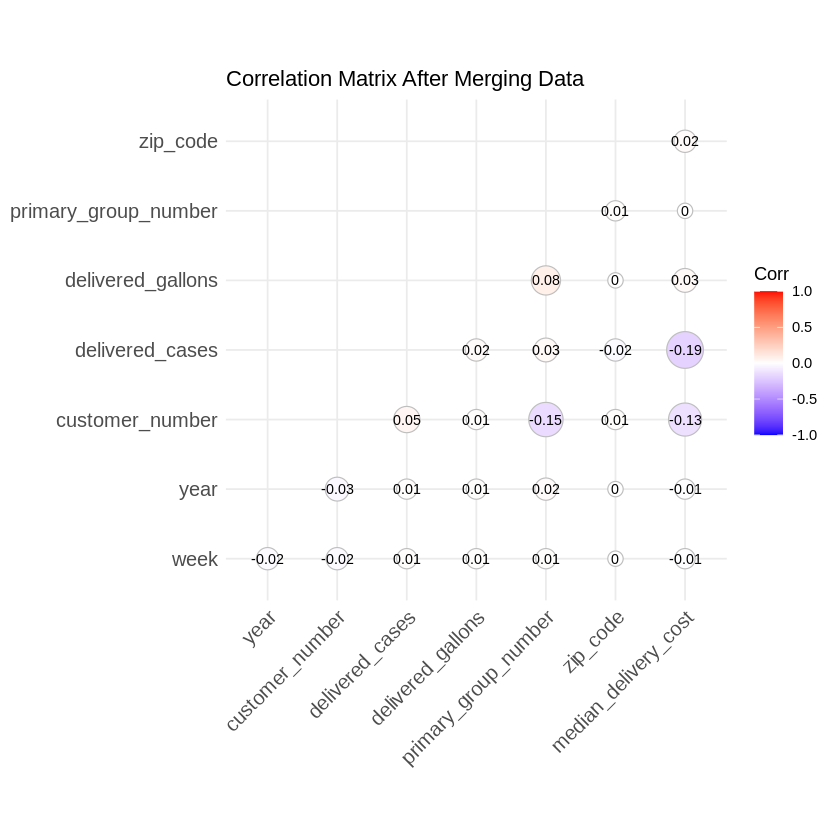

In [ ]:
# Select numeric columns only
numeric_cols_merged <- merged_data %>% select(where(is.numeric))

# Compute new correlation matrix
cor_matrix_merged <- cor(numeric_cols_merged, use = "pairwise.complete.obs")

# Visualize updated correlation matrix
ggcorrplot(cor_matrix_merged, method = "circle", type = "lower",
           lab = TRUE, lab_size = 3, title = "Correlation Matrix After Merging Data")


- The strongest correlation is between Median Delivery Cost and ZIP_CODE (0.22).

- However, all other correlations remain very weak (below 0.1).

- This suggests that even after merging customer and delivery cost data, there are no strong linear relationships between variables.

#### Check Multicollinearity Again

In [ ]:
library(car) # Load VIF package
lm_model_merged <- lm(delivered_cases ~ ., data = numeric_cols_merged)  # Adjust if needed

# Compute VIF values
vif_values_merged <- vif(lm_model_merged)

# Print new VIF values
print(vif_values_merged)

                week                 year      customer_number 
            1.000608             1.001712             1.045743 
   delivered_gallons primary_group_number             zip_code 
            1.007123             1.030922             1.000701 
median_delivery_cost 
            1.022369 


- All VIF values are low (≤ 1.07), meaning no multicollinearity issues.

- This confirms that the dataset is clean in terms of redundancy but does not contain strong linear dependencies.

##### What This Means

**1. Weak Correlations Suggest That a Linear Model Might Not Work Well**

- Since most variables show weak correlations, simple regression may not capture meaningful patterns.
- This indicates the need for non-linear modeling techniques, such as:
Decision Trees / Random Forest
Gradient Boosting (XGBoost)
Clustering (e.g., K-Means, DBSCAN)
Feature Engineering (creating meaningful new variables)

**2. Next Steps**

Instead of relying solely on correlation, we should explore feature engineering:
- ✅ Aggregating customer transactions (e.g., total purchases per customer).
- ✅ Creating categorical variables (e.g., high vs. low delivery cost categories).
- ✅ Exploring non-linear modeling techniques (e.g., tree-based models).


### **Relationships**

**Check the Merged Data**

In [ ]:
# Print the first few rows of full_data to check the result
head(merged_data)

transaction_date,week,year,customer_number,order_type,delivered_cases,delivered_gallons,primary_group_number,frequent_order_type,first_delivery_date,on_boarding_date,cold_drink_channel,trade_channel,sub_trade_channel,local_market_partner,co2_customer,zip_code,median_delivery_cost
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<dbl>,<dbl>
1/5/2023,1,2023,501202893,MYCOKE LEGACY,1.0,90.0,NA,SALES REP,5/7/2021,4/2/2021,DINING,COMPREHENSIVE DINING,FSR - MISC,TRUE,TRUE,66955,3.276188
1/6/2023,1,2023,500264574,MYCOKE LEGACY,12.5,0.0,1894,OTHER,3/23/2018,12/8/2015,WELLNESS,HEALTHCARE,OTHER HEALTHCARE,TRUE,FALSE,41603,2.921273
1/9/2023,2,2023,501174701,MYCOKE LEGACY,2.0,0.0,NA,MYCOKE360,4/12/2021,1/26/2021,DINING,FAST CASUAL DINING,OTHER FAST FOOD,TRUE,TRUE,1824,3.276188
1/11/2023,2,2023,600586532,SALES REP,16.0,2.5,8397,SALES REP,5/5/2017,2/28/1997,BULK TRADE,GENERAL,COMPREHENSIVE PROVIDER,FALSE,FALSE,1337,2.482318
1/17/2023,3,2023,501014325,SALES REP,29.0,0.0,1993,SALES REP,10/29/2019,10/25/2019,GOODS,GENERAL RETAILER,OTHER GENERAL RETAIL,TRUE,FALSE,67473,2.734069
1/23/2023,4,2023,600567384,CALL CENTER,1.5,0.0,437,SALES REP,5/15/2017,5/13/2013,GOODS,VEHICLE CARE,OTHER VEHICLE CARE,TRUE,FALSE,67060,2.734069


#### Sales Volume by Order Type

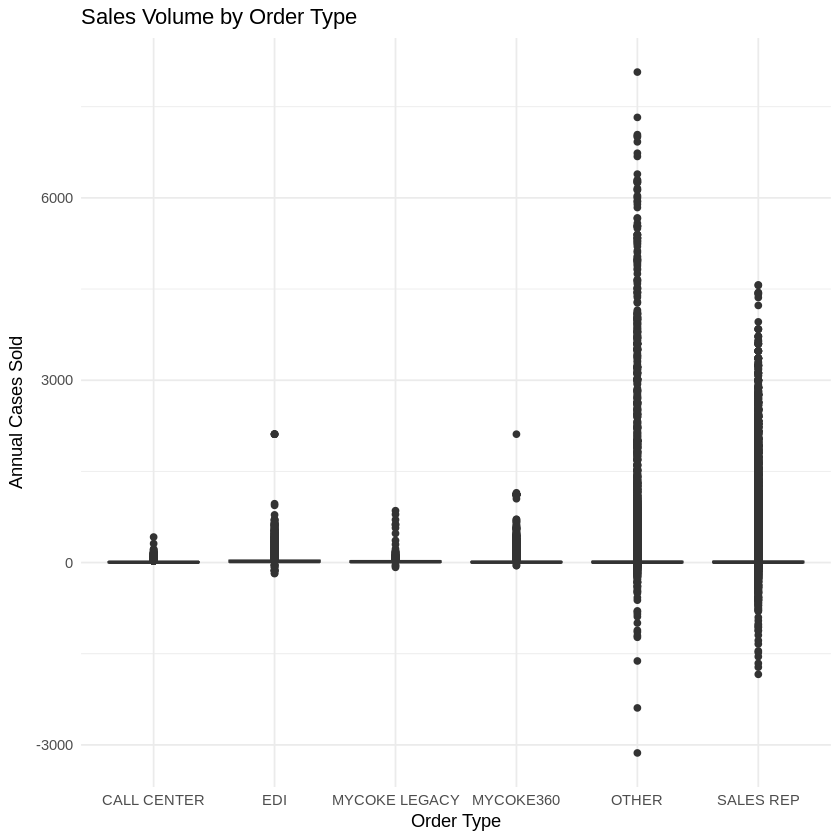

In [ ]:
# Plot the data
ggplot(merged_data, aes(x = frequent_order_type, y = delivered_cases)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Sales Volume by Order Type", x = "Order Type", y = "Annual Cases Sold")

- The majority of order types exhibit low annual sales volume, with significant outliers in categories such as "OTHER" and "SALES REP."
- "SALES REP" and "OTHER" categories display higher variance, suggesting they contribute a significant portion of sales but with a broad distribution of sales volumes.
- Digital ordering methods like "MYCOKE LEGACY" and "MYCOKE360" show relatively lower sales volume, which may indicate that customers using these methods purchase in smaller quantities.
- The presence of outliers implies that a few high-volume customers are making large purchases, possibly driving total revenue disproportionately.





### Delivery Costs vs. Volume & Channels

Loading required package: nlme


Attaching package: ‘nlme’


The following object is masked from ‘package:dplyr’:

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Warning message:
“Failed to fit group 1.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 2.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 3.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 4.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 5.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 6.
Caused by error in `gam.reparam()`:
! NA/NaN/Inf in foreign function call (arg 3)”
Warning message:
“Failed to fit group 7.
Caused by error in `ga

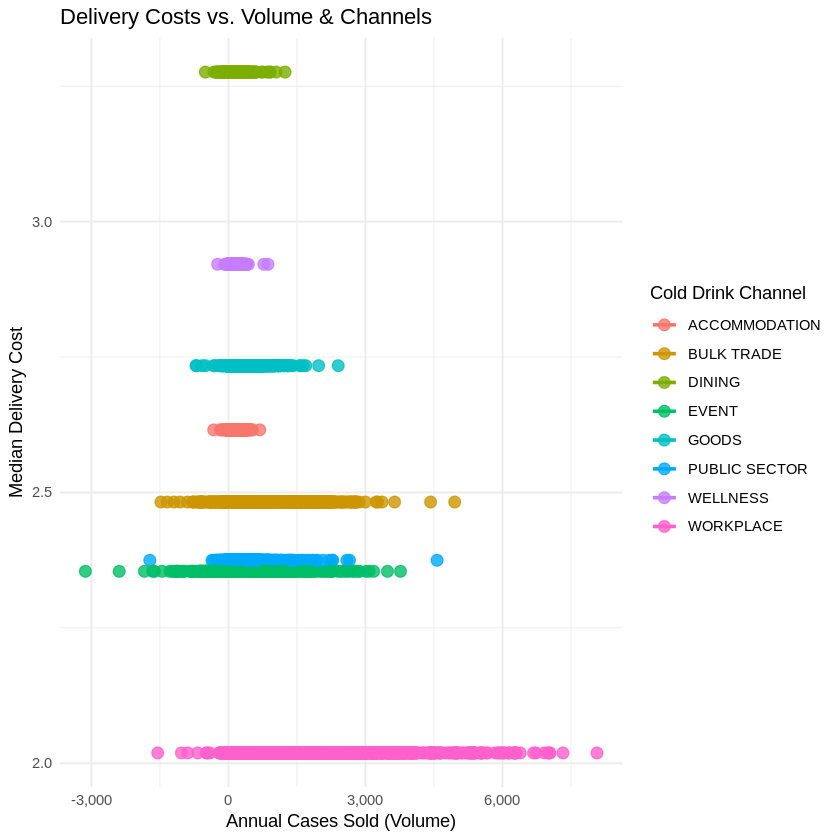

In [ ]:
suppressWarnings({
  warning("This is a warning!")
})
# Remove rows with non-finite values
cleaned_data <- merged_data %>%
  filter(is.finite(delivered_cases) & is.finite(median_delivery_cost))

library(mgcv)

ggplot(cleaned_data, aes(x = delivered_cases, y = median_delivery_cost, color = cold_drink_channel)) +
  geom_point(alpha = 0.8, size = 3) +
  geom_smooth(method = "gam", formula = y ~ s(x, bs = "cs"), se = FALSE) +  # GAM applied
  theme_minimal() +
  labs(
    title = "Delivery Costs vs. Volume & Channels",
    x = "Annual Cases Sold (Volume)",
    y = "Median Delivery Cost",
    color = "Cold Drink Channel"
  ) +
  scale_x_continuous(labels = scales::comma)


- The graph shows the relationship between Annual Cases Sold and Median Delivery Cost across different Cold Drink Channels.
- Channels like WORKPLACE and BULK TRADE demonstrate cost efficiency, with higher sales volumes correlating with lower delivery costs, indicating economies of scale.
- In contrast, channels such as ACCOMMODATION and GOODS have higher delivery costs, likely due to smaller, less frequent orders.
- The presence of negative sales volumes suggests data errors that need correction.
- Overall, the trend highlights that increasing sales volume generally leads to more stable and lower delivery costs, making high-volume channels key for optimizing delivery efficiency.

### Identifying High-Growth Customers for Direct Delivery (Red Truck)

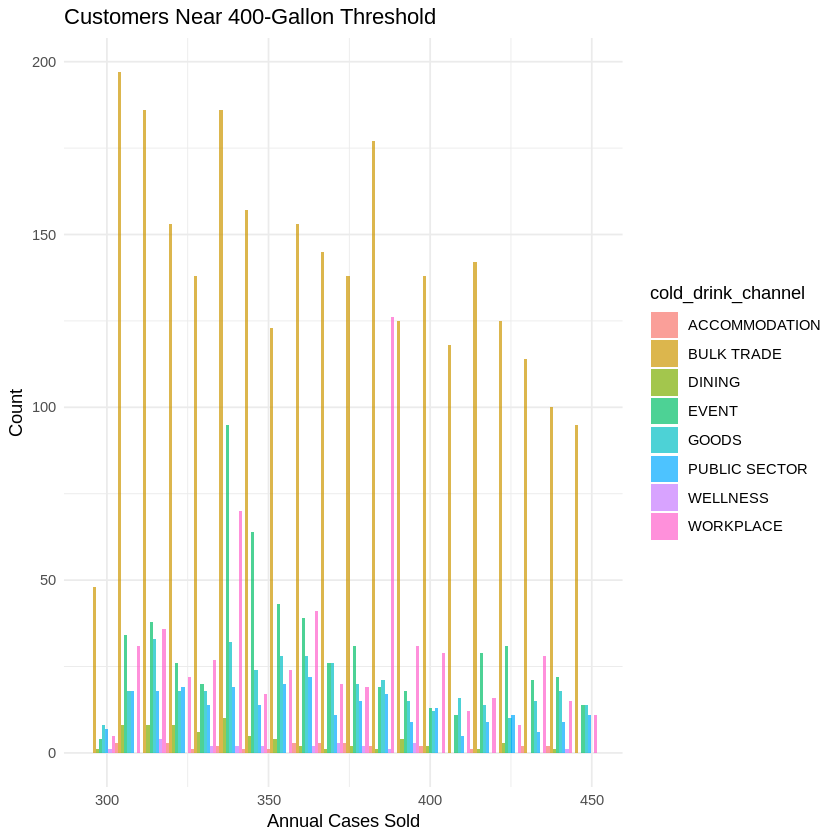

In [ ]:
# Filter customers near the 400-gallon threshold
high_potential <- cleaned_data %>%
  filter(delivered_cases > 300 & delivered_cases < 450)  # Near 400-gallon threshold

# Plot the data
ggplot(high_potential, aes(x = delivered_cases, fill = cold_drink_channel)) +
  geom_histogram(bins = 20, alpha = 0.7, position = "dodge") +
  theme_minimal() +
  labs(title = "Customers Near 400-Gallon Threshold", x = "Annual Cases Sold", y = "Count")

- The histogram illustrates the distribution of customers near the 400-gallon threshold across various Cold Drink Channels.
- The BULK TRADE channel dominates this range, with a significantly higher customer count compared to other channels, indicating a concentration of mid-volume buyers.
- Channels like EVENT, WORKPLACE, and DINING show moderate customer counts, suggesting potential for growth if these customers are retained on direct delivery routes.
- Channels such as ACCOMMODATION and WELLNESS have minimal presence in this range.
- Overall, focusing on high-potential customers near the threshold, particularly in the BULK TRADE and WORKPLACE segments, could optimize revenue by preventing premature transitions to alternate delivery models.

### **Segmentation & Clustering**

In [ ]:
library(cluster)
library(ggplot2)
library(dplyr)
library(tidyverse)

### Applying K-Means Clustering with 6 Centers

In [ ]:
# Ensure no NA/NaN/Inf in merged_data_scaled
merged_data_scaled <- merged_data %>%
  select(-transaction_date, -first_delivery_date, -on_boarding_date, -zip_code) %>%
  mutate(across(where(is.character), as.factor)) %>%
  mutate(across(where(is.factor), as.numeric)) %>%
  mutate(across(everything(), ~ ifelse(is.finite(.), ., 0)))

# Confirm row count before clustering
nrow(merged_data_scaled)


[1] 1045540

In [ ]:
apply(merged_data_scaled, 2, var)
merged_data_scaled <- merged_data_scaled %>%
  select_if(~ var(.) > 1e-8)


week                 year      customer_number 
        2.107361e+02         2.499882e-01         2.442987e+15 
          order_type      delivered_cases    delivered_gallons 
        5.234897e+00         1.476605e+04         6.338024e+02 
primary_group_number  frequent_order_type   cold_drink_channel 
        5.039834e+06         1.117690e+00         2.854512e+00 
       trade_channel    sub_trade_channel local_market_partner 
        3.974896e+01         1.359675e+02         1.455354e-01 
        co2_customer median_delivery_cost 
        2.378320e-01         1.701282e-01

In [ ]:
# Apply K-means clustering
set.seed(42)
kmeans_result <- kmeans(merged_data_scaled, centers = 6, nstart = 25)

In [ ]:
# Assign cluster labels correctly
merged_data$cluster <- as.factor(kmeans_result$cluster)

Warning message:
“Removed 1240 rows containing missing values or values outside the scale range
(`geom_point()`).”


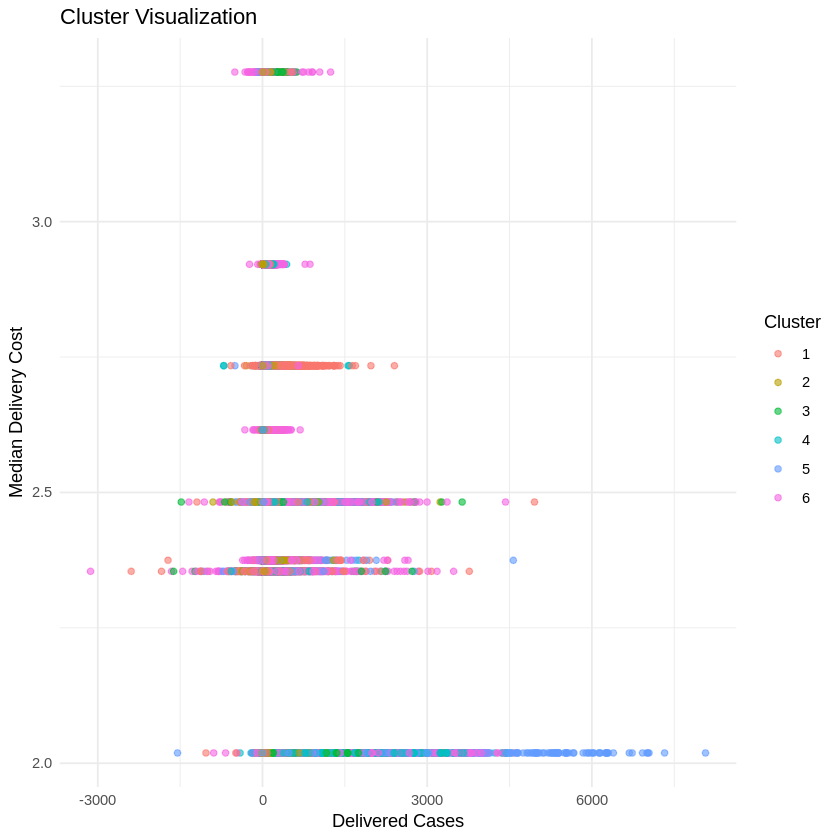

In [ ]:
suppressWarnings({
  warning("This is a warning!")
})
# Visualize the Clusters
ggplot(merged_data, aes(x = delivered_cases, y = median_delivery_cost, color = cluster)) +
  geom_point(alpha = 0.6) +
  labs(title = "Cluster Visualization",
       x = "Delivered Cases",
       y = "Median Delivery Cost",
       color = "Cluster") +
  theme_minimal()

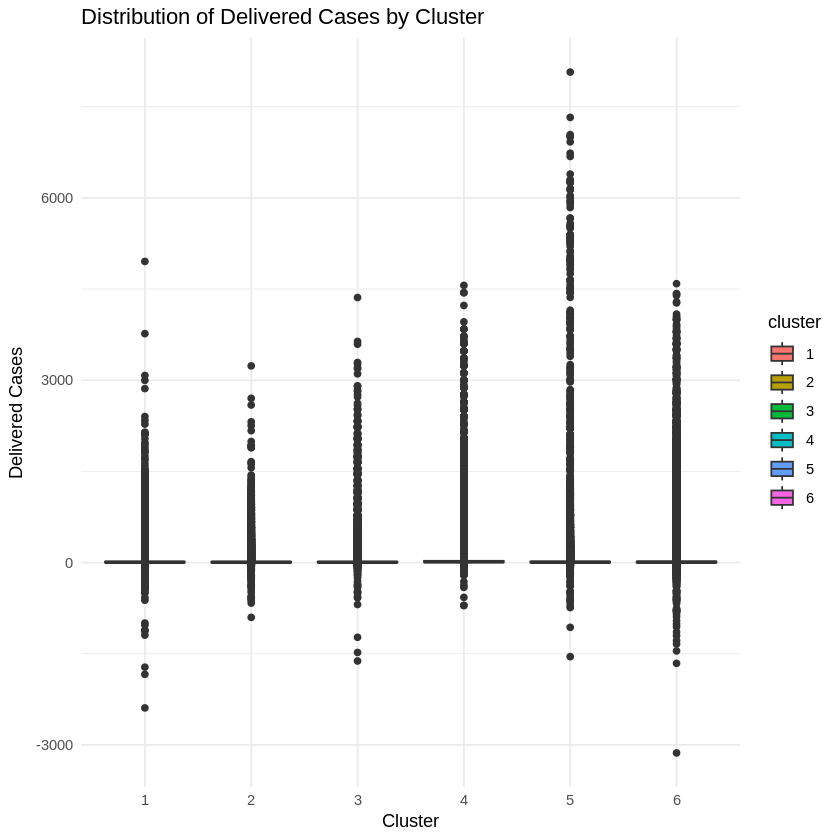

In [ ]:
# Boxplots to Compare Cluster Characteristics
ggplot(merged_data, aes(x = cluster, y = delivered_cases, fill = cluster)) +
  geom_boxplot() +
  labs(title = "Distribution of Delivered Cases by Cluster",
       x = "Cluster",
       y = "Delivered Cases") +
  theme_minimal()

In [ ]:
# Summary
merged_data %>%
  select(-week, -year, -customer_number, -zip_code, -primary_group_number) %>%
  group_by(cluster) %>%
  summarise(across(where(is.numeric), \(x) mean(x, na.rm = TRUE)))

cluster,delivered_cases,delivered_gallons,median_delivery_cost
<fct>,<dbl>,<dbl>,<dbl>
1,18.87155,9.602325,2.994400
2,18.38659,8.843162,2.931700
3,16.59392,8.510177,2.949640
4,45.77471,4.712570,2.815788
5,24.61395,8.664233,2.944311
6,27.05452,10.992836,2.866035


- Cluster 4 represents high-volume orders with a different gallon fulfillment strategy.

- Clusters 1, 2, and 3 are similar in size but might differ based on customer type or order frequency.

- Cluster 6 has the highest median delivered gallons, indicating a possible focus on larger liquid volume shipments.

- Clusters 5 and 6 have moderate delivered cases but different gallon distributions, hinting at a distinct fulfillment process.

### Cluster Count by Year After K-Means Clustering



In [ ]:
library(cluster)

In [ ]:
data_for_clustering <- merged_data_scaled %>%
  select(year, everything())
head(data_for_clustering)

year,week,customer_number,order_type,delivered_cases,delivered_gallons,primary_group_number,frequent_order_type,cold_drink_channel,trade_channel,sub_trade_channel,local_market_partner,co2_customer,median_delivery_cost
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<dbl>
2023,1,501202893,3,1.0,90.0,0,6,4,5,13,TRUE,TRUE,3.276188
2023,1,500264574,3,12.5,0.0,1894,5,8,12,31,TRUE,FALSE,2.921273
2023,2,501174701,3,2.0,0.0,0,4,4,8,27,TRUE,TRUE,3.276188
2023,2,600586532,7,16.0,2.5,8397,6,2,9,9,FALSE,FALSE,2.482318
2023,3,501014325,7,29.0,0.0,1993,6,6,10,28,TRUE,FALSE,2.734069
2023,4,600567384,1,1.5,0.0,437,6,6,26,41,TRUE,FALSE,2.734069


In [ ]:
# Run k-mean clustering
set.seed(42)
kmeans_result <- kmeans(data_for_clustering, centers = 3, nstart = 25)

# Add cluster labels
data_for_clustering$cluster <- as.factor(kmeans_result$cluster)


In [ ]:
data_for_clustering %>%
  group_by(year, cluster) %>%
  summarise(count = n(), .groups = "drop")


year,cluster,count
<dbl>,<fct>,<int>
2023,1,250729
2023,2,98515
2023,3,177150
2024,1,229833
2024,2,79606
2024,3,209707


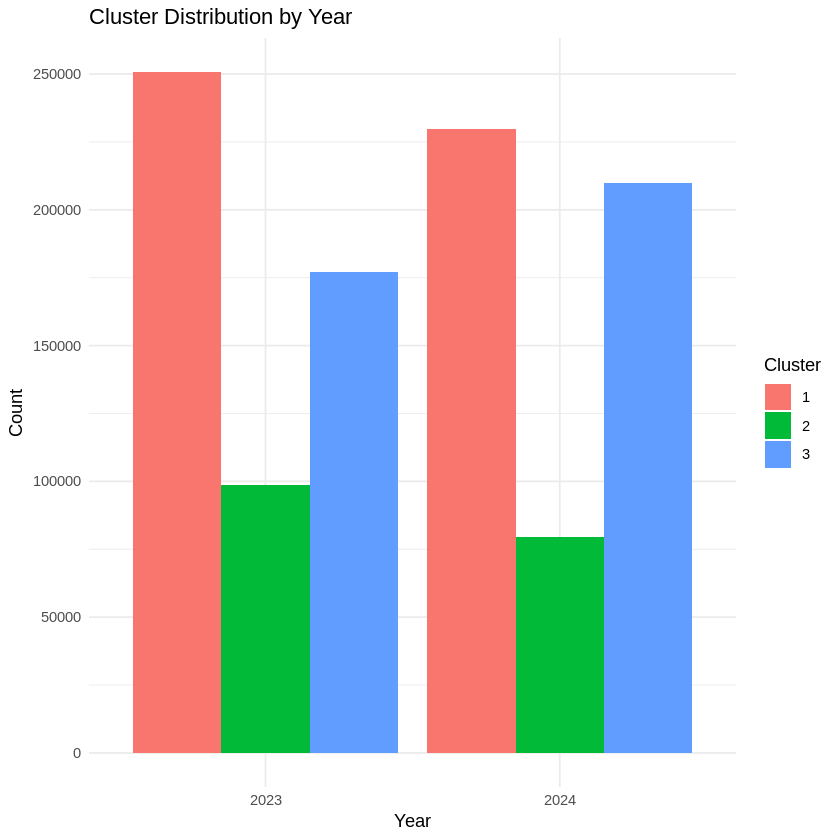

In [ ]:
ggplot(data_for_clustering, aes(x = as.factor(year), fill = cluster)) +
  geom_bar(position = "dodge") +
  labs(title = "Cluster Distribution by Year", x = "Year", y = "Count", fill = "Cluster") +
  theme_minimal()


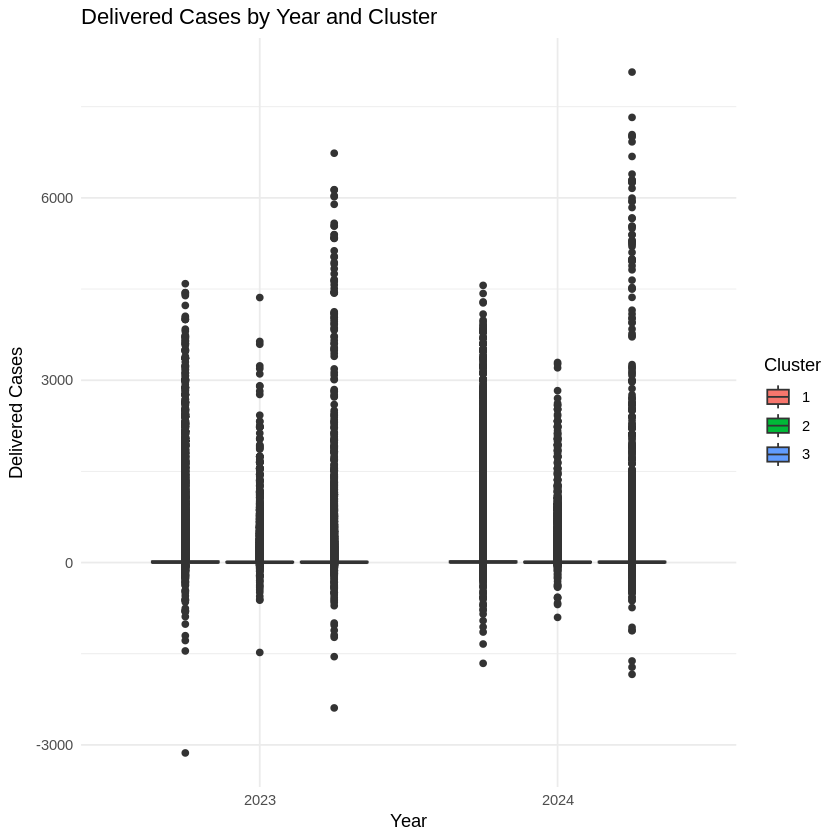

In [ ]:
ggplot(data_for_clustering, aes(x = as.factor(year), y = delivered_cases, fill = cluster)) +
  geom_boxplot() +
  labs(title = "Delivered Cases by Year and Cluster", x = "Year", y = "Delivered Cases", fill = "Cluster") +
  theme_minimal()


In [ ]:
data_for_clustering %>%
  group_by(year, cluster) %>%
  summarise(across(where(is.numeric), \(x) mean(x, na.rm = TRUE)), .groups = "drop")


year,cluster,week,customer_number,order_type,delivered_cases,delivered_gallons,primary_group_number,frequent_order_type,cold_drink_channel,trade_channel,sub_trade_channel,median_delivery_cost
<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2023,1,26.08188,600233838,3.379633,30.56126,9.215983,1452.536,5.563074,4.732005,10.87165,25.10517,2.850327
2023,2,26.05528,500556704,3.175263,17.21364,7.870704,1496.812,5.519342,4.458499,10.27244,22.16198,2.967244
2023,3,27.41314,501251232,3.661874,18.89507,9.015266,1407.107,5.397465,4.366588,11.02518,24.44036,2.960296
2024,1,25.82959,600235711,3.526939,32.63755,9.774831,1486.800,5.580835,4.714440,10.67335,24.90309,2.847003
2024,2,25.07702,500529809,3.403990,19.16107,9.158777,1465.024,5.577205,4.492739,10.28737,24.08551,2.933310
2024,3,26.35925,501336408,3.913756,21.67658,9.388598,1479.660,5.338797,4.359077,11.02576,24.32105,2.959150


- Overall Order Size Increased, suggests an increase in customer demand and possibly larger bulk orders in 2024.

- Delivered Gallons Increased in 2024

- Median Delivery Cost Remained Stable, Slight decrease in costs for Cluster 1 and Cluster 2 in 2024, suggesting better logistics efficiency or cost optimization.

- For shift in Ordering Behavior, the average week of order placement slightly shifted earlier in 2024 for Clusters 1 & 2, meaning customers may be placing orders sooner in the year compared to 2023. For cluster 3, saw a later order placement on average, which could indicate a change in seasonal demand or business strategy.

### K-Means Clustering for 2023 and 2024 Data

In [ ]:
# Split the date by year
data_2023 <- merged_data_scaled %>% filter(year == 2023)
data_2024 <- merged_data_scaled %>% filter(year == 2024)

In [ ]:
# Run k-mean clustering for 2023
set.seed(42)
kmeans_2023 <- kmeans(data_2023 %>% select(-year), centers = 3, nstart = 25)

# Add cluster labels
data_2023$cluster <- as.factor(kmeans_2023$cluster)



In [ ]:
# Run K-Means Clustering for 2024
set.seed(42)
kmeans_2024 <- kmeans(data_2024  %>% select(-year), centers = 3, nstart = 25)

# Add cluster labels
data_2024$cluster <- as.factor(kmeans_2024$cluster)


In [ ]:
### Match the labels of clusters by comparing their centroids
# Extract the centroids from different clustering results
centers_kmeans <- as.data.frame(kmeans_result$centers)
centers_kmeans <- centers_kmeans  %>% select(-year)

centers_2023 <- as.data.frame(kmeans_2023$centers)
centers_2024 <- as.data.frame(kmeans_2024$centers)


# Compute distance matrix between 2023 centroids and kmeans centroids
distance_matrix_2023 <- as.matrix(dist(rbind(centers_2023, centers_kmeans)))
distance_matrix_2023 <- distance_matrix_2023[1:3, 4:6]  # Only 2023 vs kmeans

# Compute distance matrix between 2024 centroids and kmeans centroids
distance_matrix_2024 <- as.matrix(dist(rbind(centers_2024, centers_kmeans)))
distance_matrix_2024 <- distance_matrix_2024[1:3, 4:6]  # Only 2024 vs kmeans

# Match 2023 clusters with kmeans clusters
match_2023_to_kmeans <- apply(distance_matrix_2023, 2, which.min)

# Match 2024 clusters with kmeans clusters
match_2024_to_kmeans <- apply(distance_matrix_2024, 2, which.min)

# Create mapping for 2023 and 2024 clusters to kmeans clusters
label_mapping_2023 <- data.frame(
  old_2023 = 1:3,
  new_2023 = match_2023_to_kmeans
)

label_mapping_2024 <- data.frame(
  old_2024 = 1:3,
  new_2024 = match_2024_to_kmeans
)

#print(label_mapping_2023)
#print(label_mapping_2024)

In [ ]:
data_2023$cluster <- as.factor(label_mapping_2023$new_2023[match(data_2023$cluster, label_mapping_2023$old_2023)])
data_2024$cluster <- as.factor(label_mapping_2024$new_2024[match(data_2024$cluster, label_mapping_2024$old_2024)])


In [ ]:
# Combine the clustered datasets for 2023 and 2024
merged_clustered <- bind_rows(data_2023, data_2024)



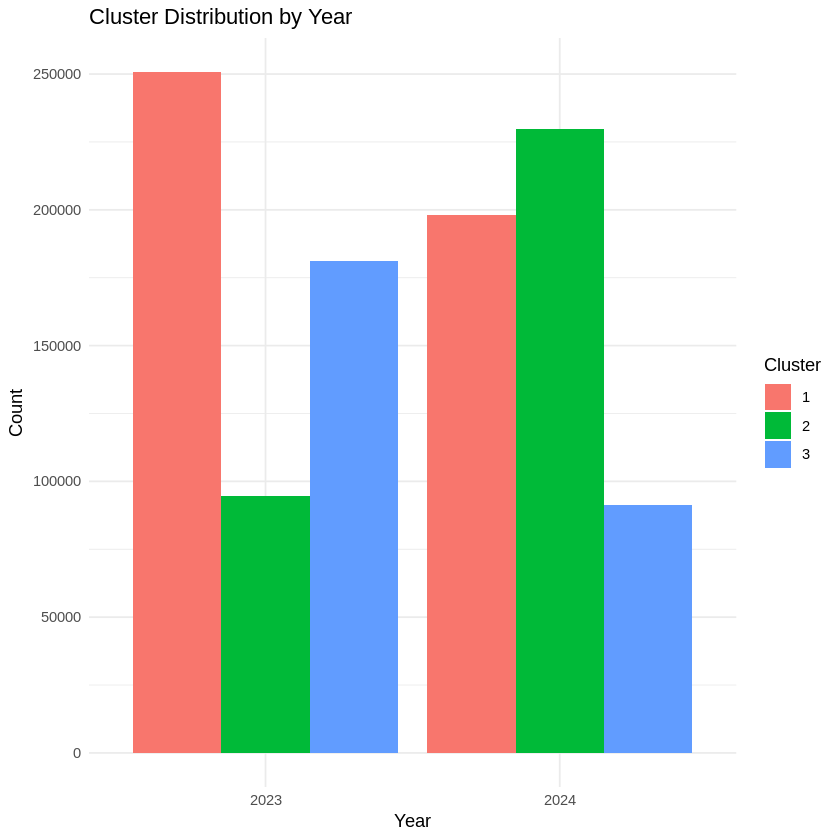

In [ ]:
ggplot(merged_clustered, aes(x = as.factor(year), fill = cluster)) +
  geom_bar(position = "dodge") +
  labs(title = "Cluster Distribution by Year", x = "Year", y = "Count", fill = "Cluster") +
  theme_minimal()


In [ ]:
# Summary of the cluster distribution for 2023
data_2023 %>%
  group_by(cluster) %>%
  summarise(count = n(), .groups = "drop")

# Summary of the cluster distribution for 2024
data_2024 %>%
  group_by(cluster) %>%
  summarise(count = n(), .groups = "drop")


cluster,count
<fct>,<int>
1,250729
2,94531
3,181134


cluster,count
<fct>,<int>
1,198119
2,229833
3,91194


- The results provide an overview of the distribution of data points across the three clusters for both years. It appears that Cluster 1 generally contains the highest number of data points, followed by Cluster 3, with Cluster 2 being the smallest in both 2023 and 2024.



<a id='Modeling'></a>
# **MODELING**


<a id='XGBoost'></a>
## **XGBOOST**




In [ ]:
  # # Load necessary library
  # library(tidyverse)
  # library(readr)
  # library(readxl)
  # library(skimr)
  # library(janitor)
  # library(dplyr)
  # library(corrr)
  # library(ggcorrplot)
  # library(car)
  # install.packages("xgboost") #, type = "source"
  # install.packages("caret")  #, dependencies = TRUE
  # library(xgboost)
  # library(dplyr)
  # library(caret)

In [ ]:
# # Load the RDS files
# merged_data_xgb <- readRDS("merged_data_xgb.rds")
# xgb_model_cases <- readRDS("xgb_model_cases.rds")
# xgb_model_gallons <- readRDS("xgb_model_gallons.rds")

In [ ]:
# # Select only numeric columns
# numeric_cols <- merged_data_xgb %>%
#   select(where(is.numeric))

# # Convert to matrix format (for modeling)
# feature_matrix <- as.matrix(numeric_cols %>% select(-c(delivered_cases, delivered_gallons)))

# # Ensure no Inf or NaN values
# feature_matrix[is.na(feature_matrix)] <- 0
# feature_matrix[is.infinite(feature_matrix)] <- 0

In [ ]:
# # Select only numeric columns
# numeric_cols <- merged_data_xgb %>%
#   select(where(is.numeric))

# # Convert to matrix format (for modeling)
# feature_matrix[is.infinite(feature_matrix)] <- 0  # Replace Inf values with 0

# # Define target variables
# target_cases <- numeric_cols$delivered_cases
# target_gallons <- numeric_cols$delivered_gallons

In [ ]:
# install.packages("caret")
# library(caret)

# # Train-test split (Run once, reuse for both targets)
# set.seed(123)
# train_index <- createDataPartition(target_cases, p = 0.8, list = FALSE)
# train_data <- feature_matrix[train_index, ]
# test_data <- feature_matrix[-train_index, ]

# # Create DMatrix (Used for both targets)
# dtrain_data <- xgb.DMatrix(data = train_data)
# dtest_data <- xgb.DMatrix(data = test_data)

In [ ]:
# # Define a Function to Train XGBoost for Any Target

# train_xgboost <- function(target_values, target_name) {

#   # Define training labels
#   train_label <- target_values[train_index]
#   test_label <- target_values[-train_index]

#   # Convert to DMatrix (add labels)
#   dtrain <- xgb.DMatrix(data = train_data, label = train_label)
#   dtest <- xgb.DMatrix(data = test_data, label = test_label)

#   # Define XGBoost Parameters
#   params <- list(
#     booster = "gbtree",
#     objective = "reg:squarederror",
#     eval_metric = "rmse",
#     eta = 0.1,
#     max_depth = 6,
#     subsample = 0.8,
#     colsample_bytree = 0.8
#   )

#   # Train XGBoost
#   xgb_model <- xgb.train(
#     params = params,
#     data = dtrain,
#     nrounds = 100,
#     watchlist = list(train = dtrain, test = dtest),
#     early_stopping_rounds = 10,
#     verbose = 1
#   )

#   # Save Model Correctly
#   saveRDS(xgb_model, paste0("xgb_model_", target_name, ".rds"))

#   # Get predictions
#   preds <- predict(xgb_model, dtest)

#   # Compute RMSE
#   rmse <- sqrt(mean((preds - test_label)^2))
#   print(paste("Final RMSE for", target_name, ":", round(rmse, 2)))

#   # Return trained model & RMSE
#   return(list(model = xgb_model, rmse = rmse))
# }

In [ ]:
# # Train Models for Both Targets

# # Train XGBoost for Delivered Cases
# model_cases <- train_xgboost(target_cases, "delivered_cases")
# model_cases

# # Train XGBoost for Delivered Gallons
# model_gallons <- train_xgboost(target_gallons, "delivered_gallons")

**Interpretation**
**Delivered Cases RMSE: 17.11**

- The model’s predicted number of delivered cases deviates by ~17 cases on average from the actual values.
- A lower RMSE means the model is now making more precise predictions for delivered cases.

**Delivered Gallons RMSE: 26.01**

- The model’s predicted number of delivered gallons deviates by ~26 gallons on average from actual values.

----
Delivered cases are now more predictable, making this model a stronger tool for forecasting deliveries.

In [ ]:
# # install.packages("xgboost")
# # library(xgboost)

# # Feature importance for Delivered Cases
# importance_cases <- xgb.importance(feature_names = colnames(feature_matrix), model = model_cases$model)
# xgb.plot.importance(importance_cases, main = "Feature Importance - Delivered Cases")

# # Feature importance for Delivered Gallons
# importance_gallons <- xgb.importance(feature_names = colnames(feature_matrix), model = model_gallons$model)
# xgb.plot.importance(importance_gallons, main = "Feature Importance - Delivered Gallons")

**Feature Importance**

**For delivered gallons, the most important features are:**

- Customer Number (most important)
- Predicted delivered cases (based on the model)
- Zip Code
- Median Delivery Cost
- Growth rate cases

- Week and Year (less important)

**For delivered cases, the most important features are:**
- Predicted delivered cases (based on the model) (most important)
- Growth rate cases
- Customer number
- Zip code
- Median Delivery Cost

- Week and Year (less important)

This suggests that customer segmentation (customer number, primary group) and location (zip code) play a key role in determining deliveries.

#### **Improve Model**

We’ll segment customers based on their order behavior using percentile-based segmentation.

Defining Segments:
- High-Volume Customers → Top 25% (large orders, frequent deliveries)
- Medium-Volume Customers → Middle 50%
- Low-Volume Customers → Bottom 25% (low deliveries, at risk of being switched to ARTM)

We will use delivered_cases, delivered_gallons, and median_delivery_cost to define these groups.

In [ ]:
# # Create Customer Segments
# library(dplyr)
# merged_data_xgb <- readRDS("merged_data_xgb.rds")
# # Create Customer Segments based on delivered_gallons
# # We’ll segment customers based on their order behavior using percentile-based segmentation.
# merged_data_xgb <- merged_data_xgb %>%
#   mutate(customer_segment = case_when(
#     delivered_gallons >= quantile(delivered_gallons, 0.75, na.rm = TRUE) ~ "High-Volume",
#     delivered_gallons > quantile(delivered_gallons, 0.25, na.rm = TRUE) ~ "Medium-Volume",
#     TRUE ~ "Low-Volume"
#   ))

# # Ensure customer_segment exists before moving to Step 2
# if (!"customer_segment" %in% colnames(merged_data_xgb)) {
#   stop("Error: customer_segment column is still missing! Check Step 1.")
# }

In [ ]:
# # Convert Customer Segment to Categorical for XGBoost

# # Ensure customer_segment exists and is not empty
# if (!"customer_segment" %in% colnames(merged_data_xgb)) stop("Error: customer_segment column not found!")
# if (sum(is.na(merged_data_xgb$customer_segment)) > 0) stop("Error: customer_segment column is empty!")

# # Convert customer_segment to factor
# merged_data_xgb$customer_segment <- as.factor(merged_data_xgb$customer_segment)

# # One-hot encode categorical variable (excluding intercept)
# dummies <- model.matrix(~ customer_segment - 1, data = merged_data_xgb)

# # Remove pre-existing customer_segment column and add the one-hot encoded columns back
# merged_data_xgb <- merged_data_xgb %>%
#   select(-customer_segment) %>%
#   bind_cols(dummies)

# # Verify dataset structure
# print(dim(merged_data_xgb))
# print(colnames(merged_data_xgb))

In [ ]:
# # Re-run XGBoost with the New Feature (Customer Segments) FOR DELIVERED CASES

# # train the XGBoost model again, this time with the customer segments included.

# # Prepare Data for XGBoost
# # Convert all categorical variables to factors
# merged_data_xgb <- merged_data_xgb %>%
#   mutate(across(where(is.character), as.factor)) %>%
#   mutate(across(where(is.factor), as.numeric))  # Convert factors to numeric

# # Add customer segments based on delivered cases
# merged_data_xgb <- merged_data_xgb %>%
#   mutate(customer_segment = case_when(
#     delivered_cases >= quantile(delivered_cases, 0.75, na.rm = TRUE) ~ "High-Volume",
#     delivered_cases > quantile(delivered_cases, 0.25, na.rm = TRUE) ~ "Medium-Volume",
#     TRUE ~ "Low-Volume"
#   ))

# # Convert the customer_segment to numeric for XGBoost compatibility
# merged_data_xgb$customer_segment <- as.factor(merged_data_xgb$customer_segment)
# merged_data_xgb$customer_segment <- as.numeric(merged_data_xgb$customer_segment)

In [ ]:
# # library(caret)
# # Split the data into training and test sets
# train_test_split <- createDataPartition(merged_data_xgb$delivered_cases, p = 0.8, list = FALSE)
# train_data <- merged_data_xgb[train_test_split, ]
# test_data <- merged_data_xgb[-train_test_split, ]

# # Prepare the feature matrix (excluding target variable 'delivered_cases')
# train_matrix <- as.matrix(train_data %>% select(-delivered_cases))
# test_matrix <- as.matrix(test_data %>% select(-delivered_cases))

# # Check for Inf and NaN values in the matrix and replace them
# train_matrix[is.infinite(train_matrix) | is.na(train_matrix)] <- 0
# test_matrix[is.infinite(test_matrix) | is.na(test_matrix)] <- 0

# # Create the DMatrix for XGBoost
# dtrain <- xgb.DMatrix(data = train_matrix, label = train_data$delivered_cases)
# dtest <- xgb.DMatrix(data = test_matrix, label = test_data$delivered_cases)

# # Define the parameters for the XGBoost model
# params <- list(
#   booster = "gbtree",
#   objective = "reg:squarederror",  # Regression task
#   eval_metric = "rmse",  # Root Mean Squared Error
#   eta = 0.1,  # Learning rate
#   max_depth = 6,  # Tree depth
#   subsample = 0.8,  # Subsampling for boosting
#   colsample_bytree = 0.8  # Feature sampling
# )

# # Train the XGBoost model
# xgb_model <- xgb.train(
#   params = params,
#   data = dtrain,
#   nrounds = 100,
#   watchlist = list(train = dtrain, test = dtest),
#   early_stopping_rounds = 10,
#   verbose = 1
# )

# # Evaluate the model performance
# preds <- predict(xgb_model, dtest)
# rmse <- sqrt(mean((preds - test_data$delivered_cases)^2))
# print(paste("Final RMSE for delivered_cases with segmentation:", round(rmse, 2)))

After segmentation it dropped **from 17.11 to 11.51**, which is great!

This result show that segmenting customers significantly improved prediction accuracy. We will just keep with delivered_cases since it has the lowest RMSE.

**Conclusion:** Segmenting customers based on delivered cases helped the model make better predictions.

#### **Exploring other segmentation with XGBoost**
##### **Segmentation for Delivered Gallons**

In [ ]:
# library(dplyr)
# # merged_data_xgb <- readRDS("merged_data_xgb.rds")
# # Define segments based on percentile-based segmentation
# merged_data_xgb <- merged_data_xgb %>%
#   mutate(customer_segment = case_when(
#     delivered_gallons >= quantile(delivered_gallons, 0.75, na.rm = TRUE) ~ "High-Volume",
#     delivered_gallons > quantile(delivered_gallons, 0.25, na.rm = TRUE) ~ "Medium-Volume",
#     TRUE ~ "Low-Volume"
#   ))

# # Check segmentation
# table(merged_data_xgb$customer_segment)

**Delivered Gallons Segmentation:**

- High-Volume: 3,937,599
- Low-Volume: 7,605,341
- Medium-Volume: 2,364,577

The majority of customers fall into the Low-Volume category, which may suggest that most customers have a relatively low number of delivered gallons.

##### **Segmentation for Delivered Cases**

In [ ]:
# # Create Customer Segments for delivered_cases (Just for comparison)
# merged_data_xgb <- merged_data_xgb %>%
#   mutate(customer_segment_cases = case_when(
#     delivered_cases >= quantile(delivered_cases, 0.75, na.rm = TRUE) ~ "High-Volume",
#     delivered_cases > quantile(delivered_cases, 0.25, na.rm = TRUE) ~ "Medium-Volume",
#     TRUE ~ "Low-Volume"
#   ))

# # Check segmentation for delivered_cases
# table(merged_data_xgb$customer_segment_cases)

**Delivered Cases Segmentation:**

- High-Volume: 3,517,701
- Low-Volume: 3,708,540
- Medium-Volume: 6,677,276

## **Modeling Conclusion**

### **XGBoost Key Findings:**
**Modeling Approach:** The XGBoost model was trained to predict delivered_cases and delivered_gallons based on customer features and historical data.

**Feature Importance:**
- Delivered Cases: The most important predictors were predicted_delivered_cases, growth_rate_cases, customer_number, zip_code, and median_delivery_cost.

- Delivered Gallons: The key predictors were customer_number, predicted_delivered_cases, zip_code, median_delivery_cost, and growth_rate_cases.

**Model Performance:**
- Delivered Cases RMSE: The model’s RMSE for delivered_cases was 17.11 without segmentation, and after segmenting by customer behavior, it improved to 11.51.

- Delivered Gallons RMSE: The RMSE for delivered_gallons was 26.01, indicating relatively higher variability in predictions.

**Segmentation Impact:**
- Customer segmentation (High, Medium, Low-Volume) based on delivered cases and gallons led to a notable improvement in prediction accuracy, particularly for delivered_cases.
- The segmentation process helped tailor the model to different customer behaviors, optimizing delivery predictions.

**Conclusion:**
Segmenting customers based on their order volumes (delivered cases and gallons) significantly enhanced the model’s performance, particularly for predicting delivered_cases. This approach could serve as a useful strategy for improving delivery forecasting accuracy in the future.

<a id='ARIMA'></a>
## **ARIMA**

<a id='Customer-segmentation-Analysis'></a>
### **Customer Segmentation Analysis**

### Data preparation

In [ ]:
str(merged_data)

tibble [1,045,540 × 19] (S3: tbl_df/tbl/data.frame)
 $ transaction_date    : chr [1:1045540] "1/5/2023" "1/6/2023" "1/9/2023" "1/11/2023" ...
 $ week                : num [1:1045540] 1 1 2 2 3 4 4 4 4 5 ...
 $ year                : num [1:1045540] 2023 2023 2023 2023 2023 ...
 $ customer_number     : num [1:1045540] 5.01e+08 5.00e+08 5.01e+08 6.01e+08 5.01e+08 ...
 $ order_type          : chr [1:1045540] "MYCOKE LEGACY" "MYCOKE LEGACY" "MYCOKE LEGACY" "SALES REP" ...
 $ delivered_cases     : num [1:1045540] 1 12.5 2 16 29 1.5 5 0 1 17 ...
 $ delivered_gallons   : num [1:1045540] 90 0 0 2.5 0 0 0 25 0 0 ...
 $ primary_group_number: num [1:1045540] NA 1894 NA 8397 1993 ...
 $ frequent_order_type : chr [1:1045540] "SALES REP" "OTHER" "MYCOKE360" "SALES REP" ...
 $ first_delivery_date : chr [1:1045540] "5/7/2021" "3/23/2018" "4/12/2021" "5/5/2017" ...
 $ on_boarding_date    : chr [1:1045540] "4/2/2021" "12/8/2015" "1/26/2021" "2/28/1997" ...
 $ cold_drink_channel  : chr [1:1045540] "DINING

In [ ]:
# Adjusting the data types in the dataframe
merged_data_arima <- merged_data %>%
  mutate(
    # Converting date columns
    first_delivery_date = as.Date(first_delivery_date, format="%m/%d/%Y"),
    on_boarding_date = as.Date(on_boarding_date, format="%m/%d/%Y"),
    transaction_date = as.Date(transaction_date, format="%m/%d/%Y"),


    # Converting numeric identifiers to factors
    customer_number = as.factor(customer_number),
    primary_group_number = as.factor(primary_group_number),
    zip_code = as.factor(zip_code),
    year = as.factor(year),

    # Converting other categorical columns to factors
    order_type = as.factor(order_type),
    frequent_order_type = as.factor(frequent_order_type),
    cold_drink_channel = as.factor(cold_drink_channel),
    trade_channel = as.factor(trade_channel),
    sub_trade_channel = as.factor(sub_trade_channel),


    local_market_partner = factor(local_market_partner, levels = c(FALSE, TRUE), labels = c("No", "Yes")),
    co2_customer = factor(co2_customer, levels = c(FALSE, TRUE), labels = c("No", "Yes")),
    primary_group_number = ifelse(is.na(primary_group_number), "Independent Store", primary_group_number)
  )

# Checking the structure of the dataframe to ensure all transformations are correct
str(merged_data_arima)


tibble [1,045,540 × 19] (S3: tbl_df/tbl/data.frame)
 $ transaction_date    : Date[1:1045540], format: "2023-01-05" "2023-01-06" ...
 $ week                : num [1:1045540] 1 1 2 2 3 4 4 4 4 5 ...
 $ year                : Factor w/ 2 levels "2023","2024": 1 1 1 1 1 1 1 1 1 1 ...
 $ customer_number     : Factor w/ 30322 levels "500245678","500245685",..: 8061 155 7686 29919 5640 28550 10327 15 6701 10538 ...
 $ order_type          : Factor w/ 7 levels "CALL CENTER",..: 3 3 3 7 7 1 3 1 1 3 ...
 $ delivered_cases     : num [1:1045540] 1 12.5 2 16 29 1.5 5 0 1 17 ...
 $ delivered_gallons   : num [1:1045540] 90 0 0 2.5 0 0 0 25 0 0 ...
 $ primary_group_number: chr [1:1045540] "Independent Store" "313" "Independent Store" "951" ...
 $ frequent_order_type : Factor w/ 6 levels "CALL CENTER",..: 6 5 4 6 6 6 6 5 6 6 ...
 $ first_delivery_date : Date[1:1045540], format: "2021-05-07" "2018-03-23" ...
 $ on_boarding_date    : Date[1:1045540], format: "2021-04-02" "2015-12-08" ...
 $ cold_drink_chan

In [ ]:

# Joing merged_data_arima to customer_address to get the address information
# Convert zip code from numeric to character
customer_address <- customer_address %>%
  rename(zip_code = zip) %>%
  mutate(zip_code = as.character(zip_code))



In [ ]:
# Ensure zip_code is of the same type
merged_data_arima$zip_code <- as.character(merged_data_arima$zip_code)
customer_address$zip_code <- as.character(customer_address$zip_code)

# Perform the left join
merged_with_address <- merged_data_arima %>%
  left_join(customer_address, by = "zip_code")

# View the results
print(merged_with_address)

# A tibble: 1,045,540 × 20
   transaction_date  week year  customer_number order_type    delivered_cases
   <date>           <dbl> <fct> <fct>           <fct>                   <dbl>
 1 2023-01-05           1 2023  501202893       MYCOKE LEGACY             1  
 2 2023-01-06           1 2023  500264574       MYCOKE LEGACY            12.5
 3 2023-01-09           2 2023  501174701       MYCOKE LEGACY             2  
 4 2023-01-11           2 2023  600586532       SALES REP                16  
 5 2023-01-17           3 2023  501014325       SALES REP                29  
 6 2023-01-23           4 2023  600567384       CALL CENTER               1.5
 7 2023-01-25           4 2023  501363682       MYCOKE LEGACY             5  
 8 2023-01-27           4 2023  500245736       CALL CENTER               0  
 9 2023-01-27           4 2023  501100933       CALL CENTER               1  
10 2023-01-31           5 2023  501372917       MYCOKE LEGACY            17  
# ℹ 1,045,530 more rows
# ℹ 14 more v

In [ ]:
# Divide full_address into columns

merged_with_address <- merged_with_address %>%
  mutate(full_address = as.character(full_address)) %>%
  # Separate the full_address into its components
  separate(full_address, into = c("zip_code_2", "city", "state", "abbreviation", "county", "street_number", "latitude", "longitude"), sep = ",", convert = TRUE) %>%
  # Convert latitude and longitude to numeric if they haven't been converted
  mutate(
    latitude = as.numeric(latitude),
    longitude = as.numeric(longitude)
  )
merged_with_address <- merged_with_address %>% select(-zip_code_2)

# View the updated data frame to ensure the conversion went correctly
print(head(merged_with_address))

# A tibble: 6 × 26
  transaction_date  week year  customer_number order_type    delivered_cases
  <date>           <dbl> <fct> <fct>           <fct>                   <dbl>
1 2023-01-05           1 2023  501202893       MYCOKE LEGACY             1  
2 2023-01-06           1 2023  500264574       MYCOKE LEGACY            12.5
3 2023-01-09           2 2023  501174701       MYCOKE LEGACY             2  
4 2023-01-11           2 2023  600586532       SALES REP                16  
5 2023-01-17           3 2023  501014325       SALES REP                29  
6 2023-01-23           4 2023  600567384       CALL CENTER               1.5
# ℹ 20 more variables: delivered_gallons <dbl>, primary_group_number <chr>,
#   frequent_order_type <fct>, first_delivery_date <date>,
#   on_boarding_date <date>, cold_drink_channel <fct>, trade_channel <fct>,
#   sub_trade_channel <fct>, local_market_partner <fct>, co2_customer <fct>,
#   zip_code <chr>, median_delivery_cost <dbl>, cluster <fct>, city <chr>,
# 

In [ ]:
# Check for missing values and data types in relevant columns
missing_data <- colSums(is.na(merged_with_address))
data_types <- sapply(merged_with_address, class)

# Combine into a single data frame for better readability
data_overview <- data.frame(
  Column = names(missing_data),
  Missing_Values = missing_data,
  Data_Type = data_types
)

# View the overview sorted by missing values in descending order
data_overview <- data_overview[order(-data_overview$Missing_Values), ]
print(data_overview)

                                   Column Missing_Values Data_Type
median_delivery_cost median_delivery_cost           1240   numeric
transaction_date         transaction_date              0      Date
week                                 week              0   numeric
year                                 year              0    factor
customer_number           customer_number              0    factor
order_type                     order_type              0    factor
delivered_cases           delivered_cases              0   numeric
delivered_gallons       delivered_gallons              0   numeric
primary_group_number primary_group_number              0 character
frequent_order_type   frequent_order_type              0    factor
first_delivery_date   first_delivery_date              0      Date
on_boarding_date         on_boarding_date              0      Date
cold_drink_channel     cold_drink_channel              0    factor
trade_channel               trade_channel              0    fa

median_delivery_cost has some missing values (1240 missing).To decide whether to use the mean or median for imputing missing values, we first need to check the skewness of the median_delivery_cost column.

In [ ]:
install.packages("e1071")
install.packages("moments")
library(e1071)
library(moments)

# Calculate skewness for `median_delivery_cost` column (excluding NAs)
skewness_value <- skewness(merged_with_address$median_delivery_cost, na.rm = TRUE)

# Print skewness value
print(paste("Skewness of median_delivery_cost:", round(skewness_value, 2)))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘proxy’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘moments’


The following objects are masked from ‘package:e1071’:

    kurtosis, moment, skewness




[1] "Skewness of median_delivery_cost: -0.47"


The skewness is -0.47, which falls between -0.5 and 0.5. This indicates that the distribution is approximately symmetric (not highly skewed).
Since the data is nearly symmetric, we should impute the missing values using the mean.

In [ ]:
# Calculate the mean of `median_delivery_cost` excluding NAs
mean_value <- mean(merged_with_address$median_delivery_cost, na.rm = TRUE)

# Impute missing values with the mean
merged_with_address$median_delivery_cost[is.na(merged_with_address$median_delivery_cost)] <- mean_value

# Verify if missing values are imputed
sum(is.na(merged_with_address$median_delivery_cost))

[1] 0

### Segment Customers Based on Delivered Volume

We will segment the customers based on growth in delivered_cases over the years 2023 and 2024. This approach is validated by a preliminary analysis, which found that focusing on delivered_cases instead of other metrics like delivered_gallons significantly improved the predictive accuracy of our models. Specifically, using delivered_cases led to a reduction in the root mean squared error (RMSE) from 17.11 to 11.51. This substantial decrease in RMSE highlights the robustness of delivered_cases as a key indicator of customer behavior and business performance. Consequently, we will calculate the growth rates for each customer based on delivered_cases and categorize these rates into high and low growth segments.

#### Aggregate the data

First, we'll calculate the total delivered_cases for each customer for each year. This involves grouping by customer_number and year, then summing up the respective columns.

In [ ]:
# Summing up cases and gallons per customer per year
yearly_totals <- merged_with_address %>%
  group_by(customer_number, year) %>%
  summarize(
    total_cases = sum(delivered_cases, na.rm = TRUE),
    .groups = 'drop'
  )

print(head(yearly_totals))

# A tibble: 6 × 3
  customer_number year  total_cases
  <fct>           <fct>       <dbl>
1 500245678       2023        220  
2 500245678       2024        144  
3 500245685       2023         23  
4 500245685       2024         32  
5 500245686       2023         15.5
6 500245686       2024         16  


#### Calculate Growth Rates

Next, we'll calculate the growth rates from 2023 to 2024 for each customer. We'll need to pivot the data so that the totals for each year are in separate columns, then calculate the growth rate.

In [ ]:
# Reshaping the data to wide format
yearly_wide <- yearly_totals %>%
  pivot_wider(
    names_from = year,
    values_from = total_cases,
    names_glue = "year_{year}_{.value}"
  )

# Calculating growth rates
yearly_growth <- yearly_wide %>%
  mutate(
    growth_rate = (year_2024_total_cases - year_2023_total_cases) / year_2023_total_cases * 100,
  )%>%
  filter(!is.na(growth_rate))

# Check results
print(head(yearly_growth))

# A tibble: 6 × 4
  customer_number year_2023_total_cases year_2024_total_cases growth_rate
  <fct>                           <dbl>                 <dbl>       <dbl>
1 500245678                       220                    144       -34.5 
2 500245685                        23                     32        39.1 
3 500245686                        15.5                   16         3.23
4 500245689                       124                    148.       19.8 
5 500245690                        70                     39       -44.3 
6 500245698                       275                    269        -2.18


####  Reviewing Growth Rates

Given the potential for extreme values in growth calculations—such as negative values or infinities when a customer starts from zero cases in 2023—we will inspect the summary statistics to decide on further actions like capping extreme growth rates or treating infinities.

In [ ]:
# Check the summary of adjusted growth rates
summary(yearly_growth$growth_rate)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   -Inf -26.039  -2.256          27.660     Inf 

The summary statistics reveal the presence of extreme values in our growth rate calculations, including negative and positive infinite values. These extremes typically occur when the previous year's cases are zero, leading to a division by zero in our growth rate calculation.

##### Handling Infinite Growth Rates


For customers with zero cases in the base year (leading to infinite growth rates), we will assign a default high growth rate of 100%, acknowledging the initiation of their transaction activity.

In [ ]:
# Assuming customers with Inf growth started in 2024
yearly_growth <- yearly_growth %>%
  mutate(
    growth_rate = replace(growth_rate, is.infinite(growth_rate), 100)
  )
# Capping extreme growth rates at 200% and -100%
yearly_growth$growth_rate <- pmin(pmax(yearly_growth$growth_rate, -100), 200)

In [ ]:
# Check the summary of adjusted growth rates
summary(yearly_growth$growth_rate)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-100.000  -26.016   -2.245   10.716   27.663  200.000 

#### Segmenting Customers into High and Low Growth

In [ ]:
# Calculate the 75th quantile as the threshold for high growth
growth_threshold <- quantile(yearly_growth$growth_rate, 0.75, na.rm = TRUE)

# Create a new column for growth segment based on the threshold
yearly_growth <- yearly_growth %>%
  mutate(
    growth_segment = ifelse(growth_rate >= growth_threshold, "High Growth", "Low Growth")
  )

# Check the distribution of segments
table(yearly_growth$growth_segment)

# View some of the data to confirm
head(yearly_growth)


High Growth  Low Growth 
       5148       15443 

customer_number,year_2023_total_cases,year_2024_total_cases,growth_rate,growth_segment
<fct>,<dbl>,<dbl>,<dbl>,<chr>
500245678,220.0,144.0,-34.545455,Low Growth
500245685,23.0,32.0,39.130435,High Growth
500245686,15.5,16.0,3.225806,Low Growth
500245689,124.0,148.5,19.758065,Low Growth
500245690,70.0,39.0,-44.285714,Low Growth
500245698,275.0,269.0,-2.181818,Low Growth


In [ ]:
# Filter the data for 'High Growth' segment
high_growth_customers <- yearly_growth %>%
  filter(growth_segment == "High Growth")
print(high_growth_customers)

# A tibble: 5,148 × 5
   customer_number year_2023_total_cases year_2024_total_cases growth_rate
   <fct>                           <dbl>                 <dbl>       <dbl>
 1 500245685                        23                    32          39.1
 2 500245794                        24                    42          75  
 3 500245831                         3                     4          33.3
 4 500245898                        23                    34.5        50  
 5 500245926                        94.5                 130.         37.0
 6 500245942                         0                     7         100  
 7 500246026                         0                     0.5       100  
 8 500246030                       199                   326          63.8
 9 500246087                        49.9                  68.5        37.2
10 500246096                        59                   119         102. 
# ℹ 5,138 more rows
# ℹ 1 more variable: growth_segment <chr>


In [ ]:
high_growth_customers_2 <- high_growth_customers %>%
  select(-year_2023_total_cases, -year_2024_total_cases,-growth_segment)
# Join 'high_growth_customers' with 'merged_with_address' on 'customer_number'
customers_high_growth <- high_growth_customers_2 %>%
  left_join(merged_with_address, by = "customer_number")
print(head(customers_high_growth))

# A tibble: 6 × 27
  customer_number growth_rate transaction_date  week year  order_type   
  <fct>                 <dbl> <date>           <dbl> <fct> <fct>        
1 500245685              39.1 2023-04-07          14 2023  MYCOKE LEGACY
2 500245685              39.1 2024-02-23           8 2024  MYCOKE LEGACY
3 500245685              39.1 2023-06-09          23 2023  MYCOKE LEGACY
4 500245685              39.1 2023-03-17          11 2023  MYCOKE LEGACY
5 500245685              39.1 2024-05-17          20 2024  MYCOKE LEGACY
6 500245685              39.1 2023-03-03           9 2023  MYCOKE LEGACY
# ℹ 21 more variables: delivered_cases <dbl>, delivered_gallons <dbl>,
#   primary_group_number <chr>, frequent_order_type <fct>,
#   first_delivery_date <date>, on_boarding_date <date>,
#   cold_drink_channel <fct>, trade_channel <fct>, sub_trade_channel <fct>,
#   local_market_partner <fct>, co2_customer <fct>, zip_code <chr>,
#   median_delivery_cost <dbl>, cluster <fct>, city <chr>, state <

In [ ]:
#write.csv(customers_high_growth, "customers_high_growth.csv", row.names = FALSE)

#### High growth customers exploration

##### Analyzing local_market_partner Distribution

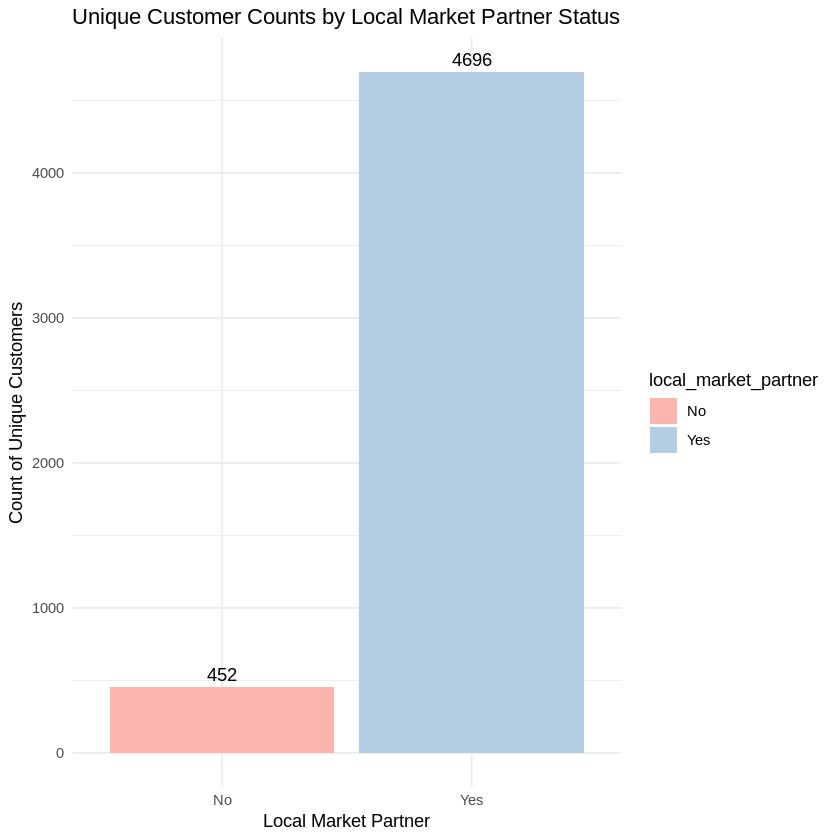

In [ ]:
# Calculate the number of unique customer IDs for each local_market_partner category
unique_customers_by_partner <- customers_high_growth %>%
  group_by(local_market_partner) %>%
  summarise(unique_customers = n_distinct(customer_number), .groups = 'drop')

# Create a bar chart with these counts
ggplot(unique_customers_by_partner, aes(x = local_market_partner, y = unique_customers, fill = local_market_partner)) +
  geom_bar(stat = "identity") +  # stat="identity" to use the actual values in y
  geom_text(aes(label = unique_customers), vjust = -0.5) +  # Adding count labels above bars
  labs(title = "Unique Customer Counts by Local Market Partner Status",
       x = "Local Market Partner", y = "Count of Unique Customers") +
  scale_fill_brewer(palette = "Pastel1") +  # Optional: Adding color palette for aesthetics
  theme_minimal()

The bar chart illustrates the distribution of customers by their status with a local market partner. It shows a significant disparity, with a far greater number of unique customers (4,696) partnered locally compared to those who are not (452). This indicates that the majority of high-growth customers are engaged with local market partners, suggesting a possible correlation between such partnerships and customer growth or retention.

##### Analyzing co2_customer Distribution

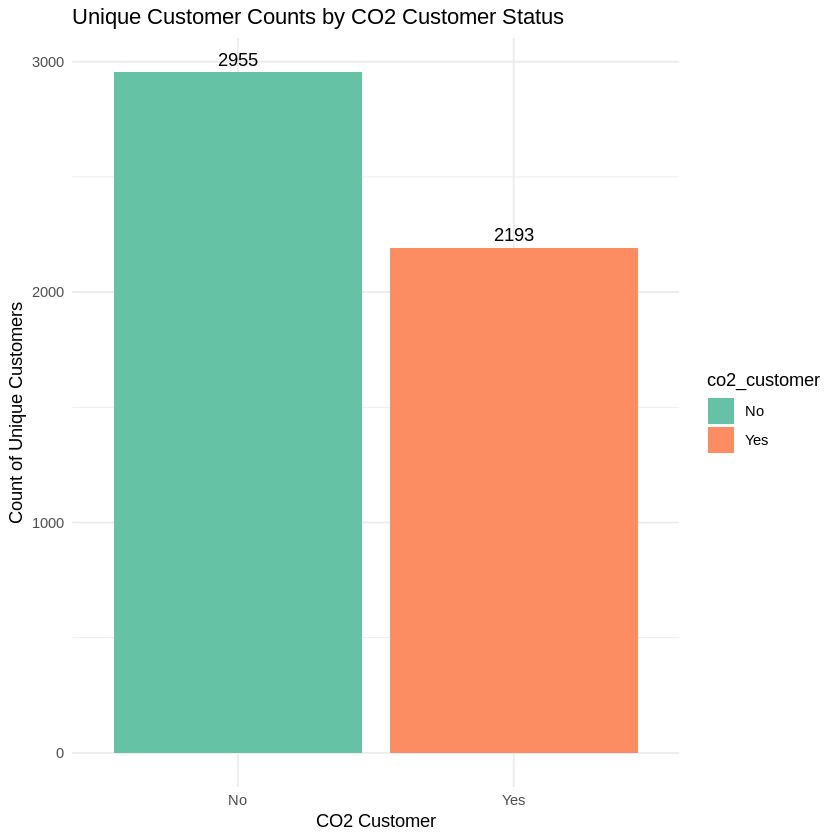

In [ ]:
# Calculate the number of unique customer IDs for each CO2 customer category
unique_customers_by_co2 <- customers_high_growth %>%
  group_by(co2_customer) %>%
  summarise(unique_customers = n_distinct(customer_number), .groups = 'drop')

# Create a bar chart with these counts
ggplot(unique_customers_by_co2, aes(x = co2_customer, y = unique_customers, fill = co2_customer)) +
  geom_bar(stat = "identity") +  # stat="identity" tells ggplot to use the data as is
  geom_text(aes(label = unique_customers), vjust = -0.5) +  # Adding count labels above bars
  labs(title = "Unique Customer Counts by CO2 Customer Status",
       x = "CO2 Customer", y = "Count of Unique Customers") +
  scale_fill_brewer(palette = "Set2") +  # Optional: Adding color palette for aesthetics
  theme_minimal()

The bar chart presents the distribution of unique high-growth customers based on whether they purchase CO2 products. It shows that a slightly larger number of customers do not purchase CO2 products (2,955) compared to those who do (2,193). This data suggests a substantial engagement in CO2-related purchases among high-growth customers, although non-CO2 customers slightly outnumber them.

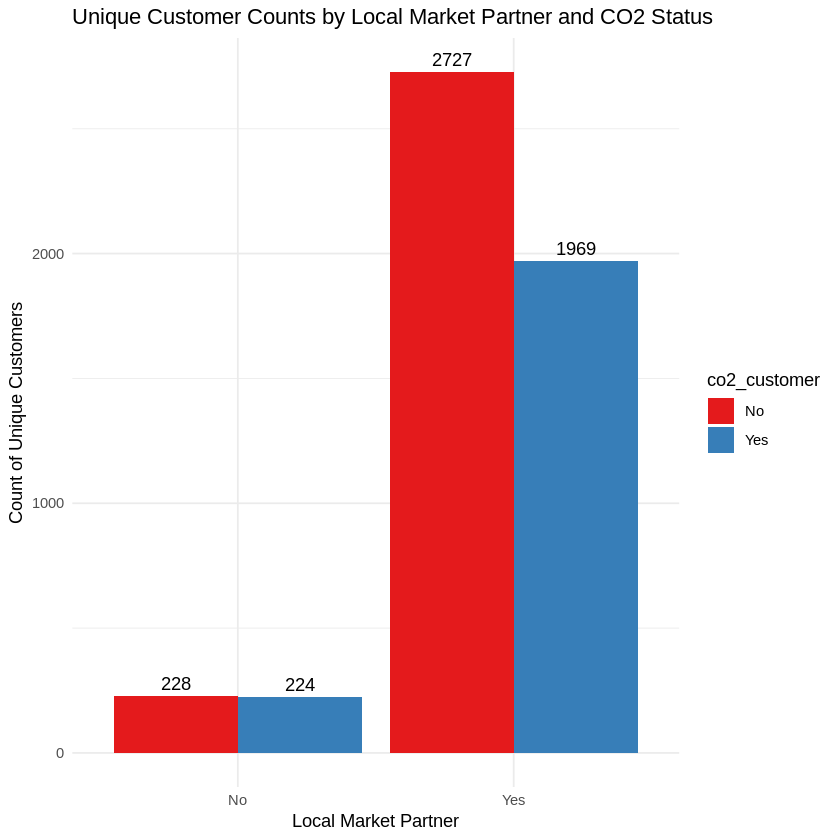

In [ ]:
# Calculate the number of unique customer IDs for each combination of local_market_partner and co2_customer
unique_customers_by_partner_co2 <- customers_high_growth %>%
  group_by(local_market_partner, co2_customer) %>%
  summarise(unique_customers = n_distinct(customer_number), .groups = 'drop')

# Create a bar chart with these counts
ggplot(unique_customers_by_partner_co2, aes(x = local_market_partner, y = unique_customers, fill = co2_customer)) +
  geom_bar(stat = "identity", position = "dodge") +  # Using dodge to distinguish the bars side-by-side
  geom_text(aes(label = unique_customers), vjust = -0.5, position = position_dodge(width = 0.9)) +  # Adding count labels above bars
  labs(title = "Unique Customer Counts by Local Market Partner and CO2 Status",
       x = "Local Market Partner", y = "Count of Unique Customers") +
  scale_fill_brewer(palette = "Set1") +  # Applying a color palette
  theme_minimal()

The bar chart shows unique high-growth customers, revealing that those local market partner are more likely to purchase CO2 products (1,969) compared to those without a partner (224). However, the majority of partnered customers do not buy CO2 products (2,727), indicating varied purchasing behaviors within this group.

#####  Geographic Distribution by state

Analyzing the geographic distribution can help identify where high growth customers are located, potentially informing regional marketing strategies.

In [ ]:
# Calculate the number of unique customer IDs for each state
unique_customers_by_state <- customers_high_growth %>%
  group_by(state) %>%
  summarise(unique_customers = n_distinct(customer_number), .groups = 'drop')

# Check the first few entries
head(unique_customers_by_state)

state,unique_customers
<chr>,<int>
Kansas,1215
Kentucky,1205
Louisiana,73
Maryland,808
Massachusetts,1847


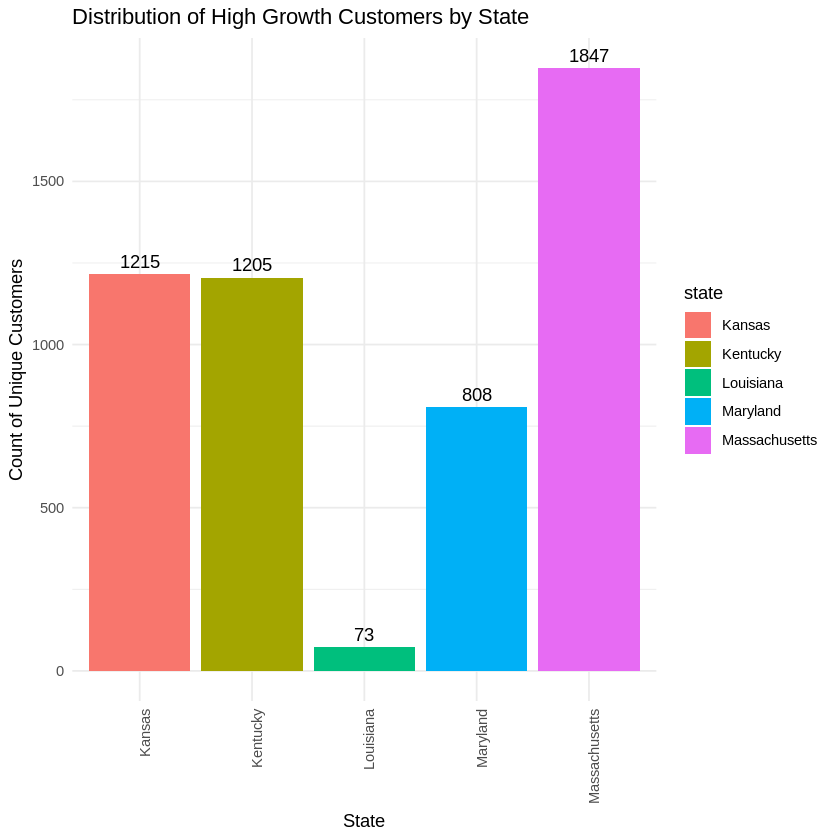

In [ ]:
# Create a bar chart with labels showing the number of unique customers
ggplot(unique_customers_by_state, aes(x = state, y = unique_customers, fill = state)) +
  geom_bar(stat = "identity") +  # Use the actual values in unique_customers for the heights of the bars
  geom_text(aes(label = unique_customers), vjust = -0.5) +  # Adding count labels above bars
  labs(title = "Distribution of High Growth Customers by State",
       x = "State", y = "Count of Unique Customers") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1))  # Rotate state labels for readability

The bar chart illustrates the distribution of high-growth customers across different states, revealing significant geographical disparities in customer concentration. Massachusetts has the highest number of unique high-growth customers (1,847), indicating a strong market presence. Both Kansas and Kentucky also show substantial numbers, with over 1,200 unique customers each. In contrast, Louisiana has notably fewer high-growth customers, with just 73, suggesting potential areas for market expansion or focused marketing strategies.

##### Geographical Analysis by City

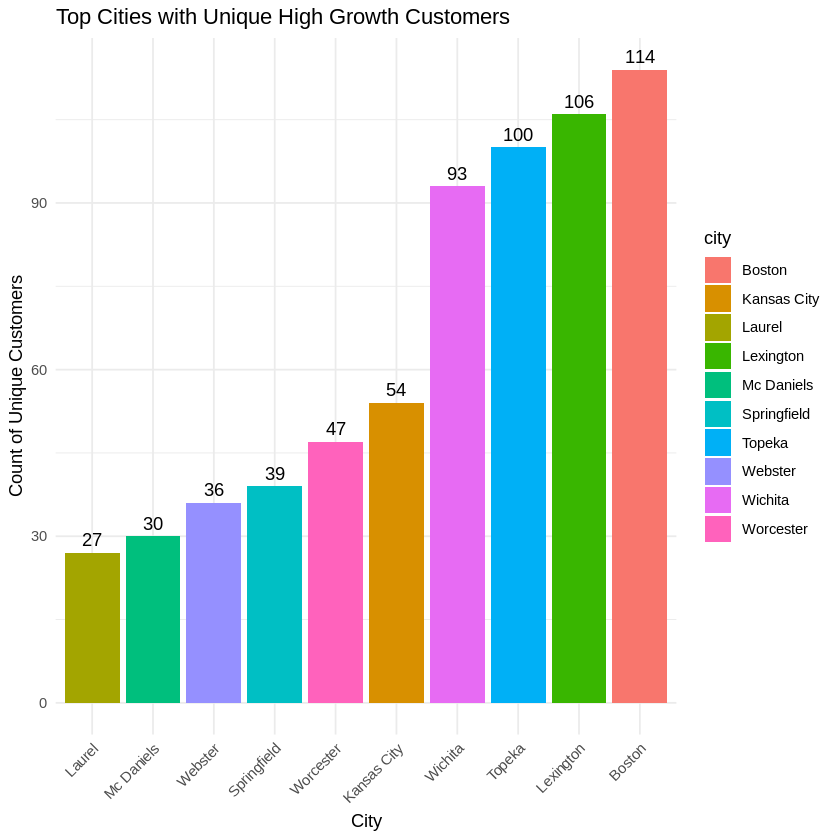

In [ ]:
# Calculate the number of unique customer IDs for each city
unique_customers_by_city <- customers_high_growth %>%
  group_by(city) %>%
  summarise(unique_customers = n_distinct(customer_number), .groups = 'drop')
top_cities_unique <- unique_customers_by_city %>%
  arrange(desc(unique_customers)) %>%
  slice_head(n = 10)

# Create a bar chart with labels showing the number of unique customers
ggplot(top_cities_unique, aes(x = reorder(city, unique_customers), y = unique_customers, fill = city)) +
  geom_bar(stat = "identity") +  # Use the actual values in unique_customers for the heights of the bars
  geom_text(aes(label = unique_customers), vjust = -0.5) +  # Adding count labels above bars
  labs(title = "Top Cities with Unique High Growth Customers",
       x = "City", y = "Count of Unique Customers") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The bar chart shows the distribution of unique high-growth customers across the top cities. Boston leads with the highest number of unique customers at 114, followed closely by Lexington and Topeka with 106 and 100 customers, respectively. This visualization highlights the urban centers driving high growth, with Boston standing out as a particularly significant hub for such customers. The data also suggests potential areas for focused marketing and expansion efforts, especially in cities like Boston and Lexington, where the concentration of high-growth customers is notably high.

#####  Analyzing Meadian Delivery cost

Investigate the median_delivery_cost to see if there's a relationship between delivery costs and customer growth.


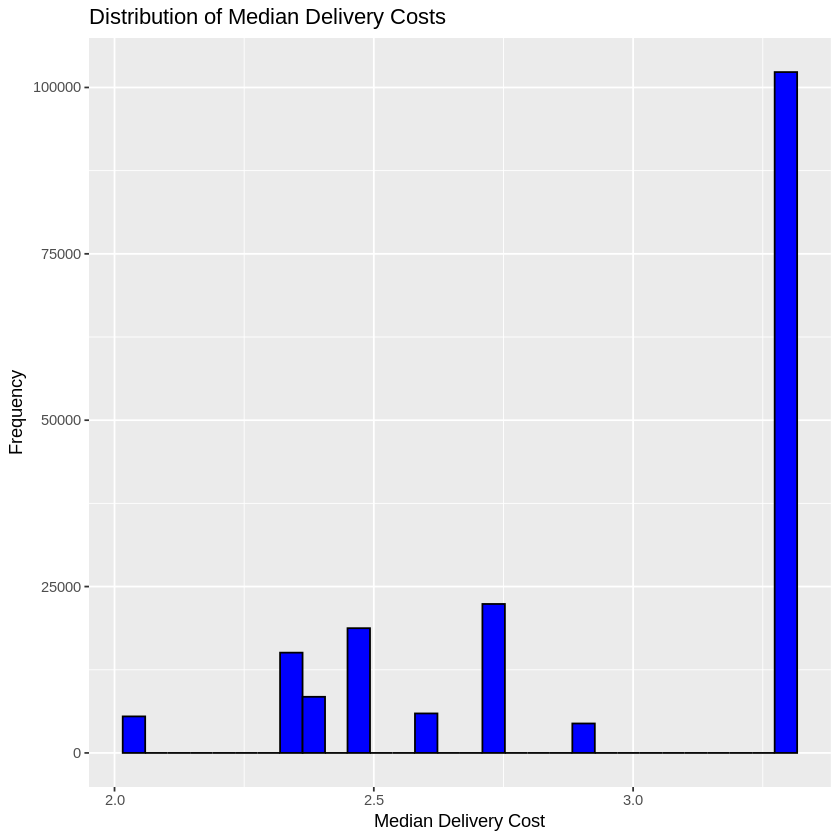

In [ ]:
# Histogram to visualize the distribution of delivery costs
ggplot(customers_high_growth, aes(x = median_delivery_cost)) +
  geom_histogram(bins = 30, fill = "blue", color = "black") +
  labs(title = "Distribution of Median Delivery Costs", x = "Median Delivery Cost", y = "Frequency")


In [ ]:
# Get summary statistics for median_delivery_cost
summary(customers_high_growth$median_delivery_cost)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  2.019   2.482   3.276   2.943   3.276   3.276 

In [ ]:
# Calculate correlation between median_delivery_cost and growth_rate
correlation <- cor(customers_high_growth$median_delivery_cost, customers_high_growth$growth_rate, use = "complete.obs")
print(paste("Correlation between delivery costs and growth rate:", correlation))

[1] "Correlation between delivery costs and growth rate: 0.182581709286271"


The histogram showcases the distribution of median delivery costs for high-growth customers, with a notable spike at a delivery cost of 3.0, suggesting a high frequency of customers paying this amount. The summary statistics support this observation, indicating that the maximum, median, and third quartile values are all at 3.276. The correlation between delivery costs and growth rate is moderately positive (0.204), hinting that higher delivery costs might be associated with greater customer growth, possibly due to the value or quality of service perceived by these customers.

##### Growth Rate Analysis

Further analyze the growth_rate column to see the range and distribution of growth rates among high growth customers.

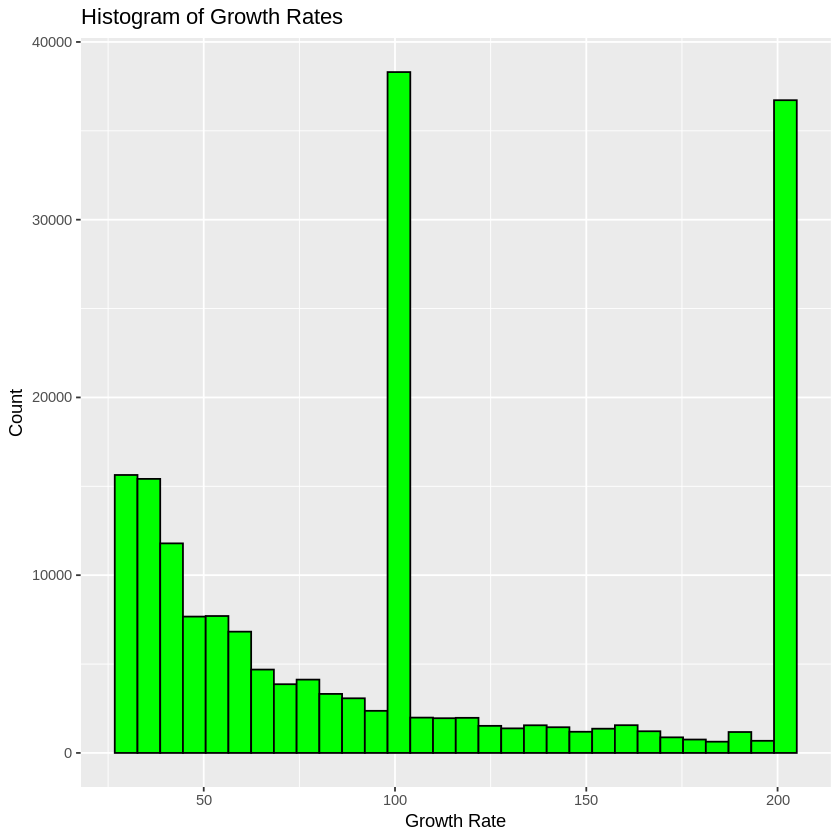

In [ ]:
# Histogram of growth rates
ggplot(customers_high_growth, aes(x = growth_rate)) +
  geom_histogram(bins = 30, fill = "green", color = "black") +
  labs(title = "Histogram of Growth Rates", x = "Growth Rate", y = "Count")



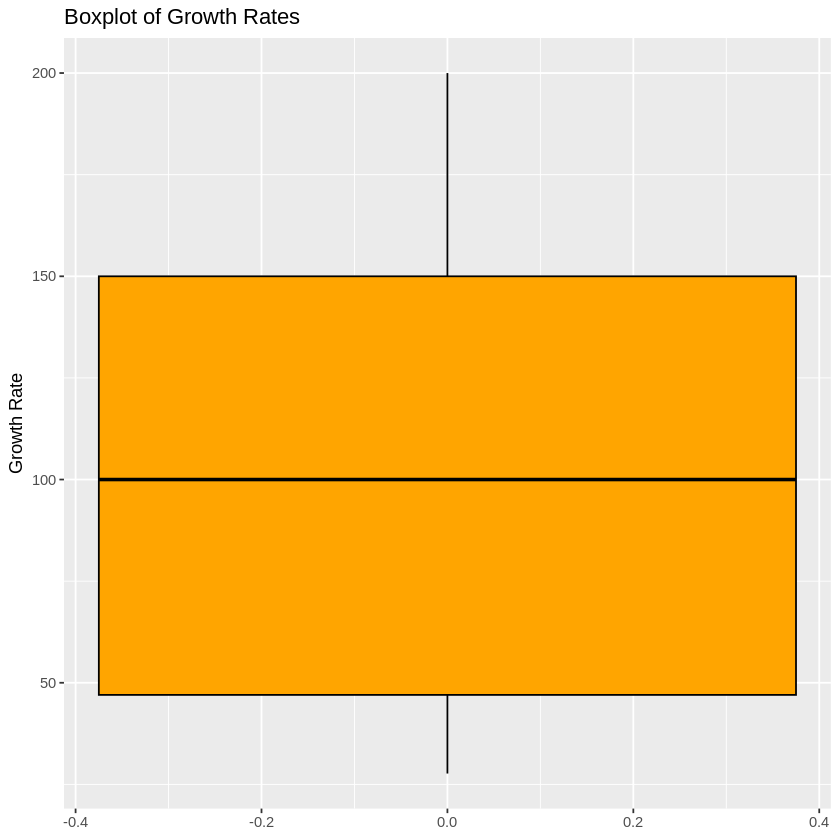

In [ ]:
# Boxplot to identify outliers
ggplot(customers_high_growth, aes(y = growth_rate)) +
  geom_boxplot(fill = "orange", color = "black") +
  labs(title = "Boxplot of Growth Rates", y = "Growth Rate")

These charts suggest that while a substantial number of customers experience very high growth rates, the typical high-growth customer tends to have a growth rate clustered around 100%. This indicates a standard high-growth pattern among a significant portion of the customer base, with a smaller yet notable group achieving exceptionally high growth.

##### Distribution of Order Types

Analyze the types of orders placed by high-growth customers to see if certain order types are more prevalent.

Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


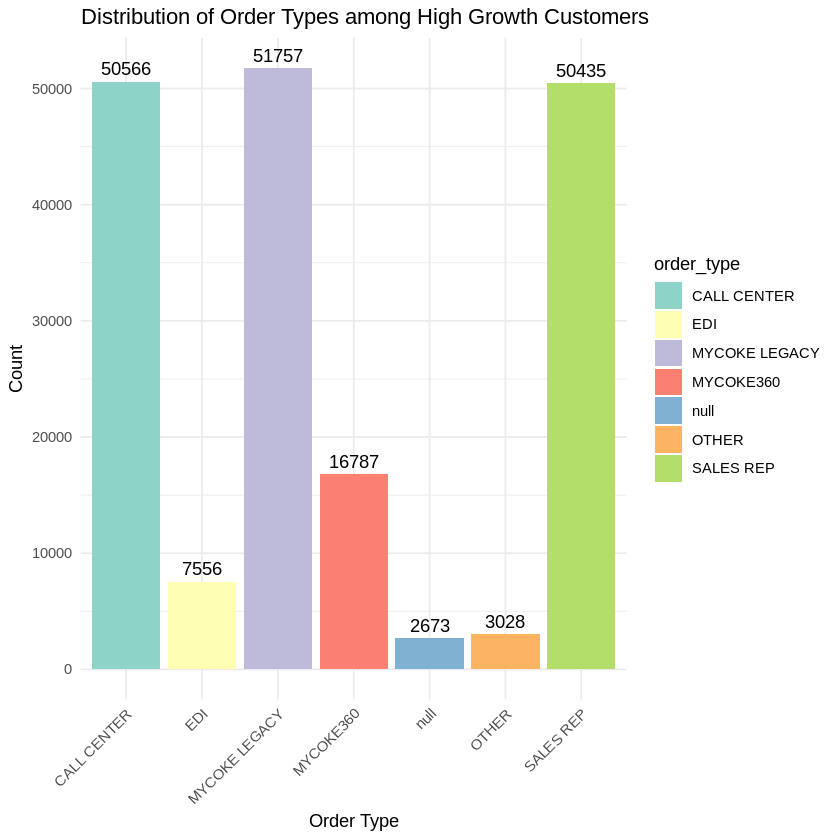

In [ ]:
# Plot the distribution of order types among high growth customers with counts on the bars
ggplot(customers_high_growth, aes(x = order_type, fill = order_type)) +
  geom_bar() +
  geom_text(stat='count', aes(label=..count..), vjust=-0.5) + # Adding count labels above bars
  scale_fill_brewer(palette="Set3") +  # This adds a distinct color palette
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +  # Rotating x-axis labels for better readability
  labs(title = "Distribution of Order Types among High Growth Customers",
       x = "Order Type",
       y = "Count")

The bar chart illustrates the distribution of order types among high-growth customers. It shows that "Sales Rep" is the most prevalent order type, followed closely by "Call Center" and "MyCoke Legacy." These three categories dominate, suggesting that traditional and legacy order methods are preferred among these customers. In contrast, "EDI" and "MyCoke360" have significantly fewer counts, indicating lesser usage among the high-growth customer segment. This distribution highlights the ongoing reliance on direct sales and traditional customer service channels over newer, digital methods.

##### Transaction Frequency Over Time

Evaluate how frequently these customers place orders and how this might correlate with their growth.

`geom_smooth()` using formula = 'y ~ x'


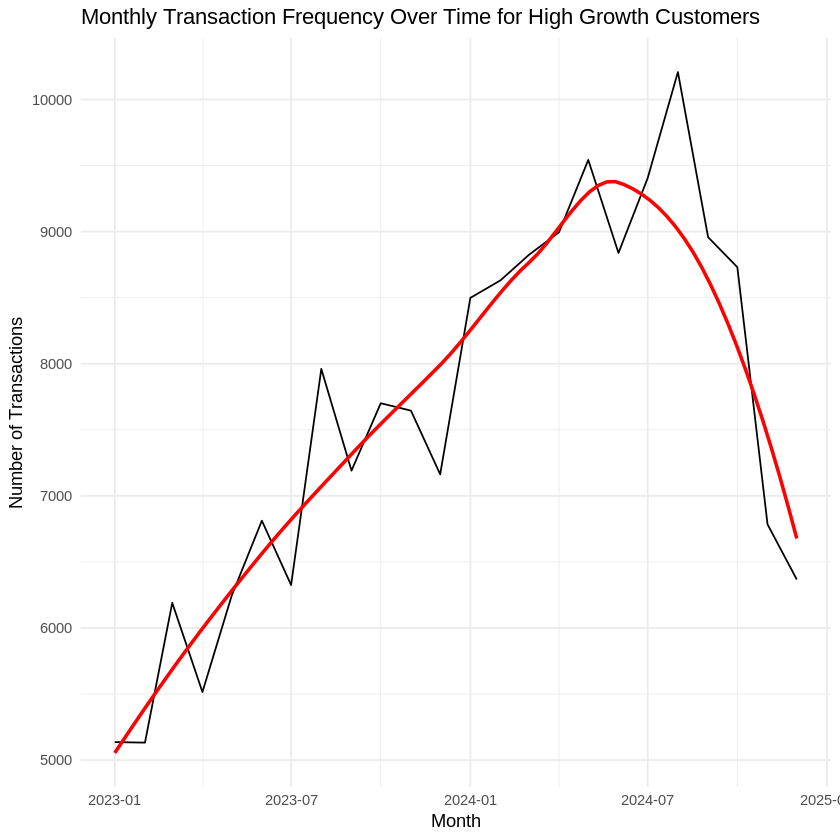

In [ ]:
# Aggregating transactions on a monthly basis for smoother visualization
customers_high_growth %>%
  mutate(month = floor_date(transaction_date, unit = "month")) %>%
  group_by(month) %>%
  summarise(total_transactions = n(), .groups = 'drop') %>%
  ggplot(aes(x = month, y = total_transactions)) +
  geom_line() +
  geom_smooth(method = "loess", color = "red", se = FALSE) +  # Adding a smoothed trend line
  theme_minimal() +
  labs(title = "Monthly Transaction Frequency Over Time for High Growth Customers",
       x = "Month",
       y = "Number of Transactions")

The line graph depicts the transaction frequency over time for high-growth customers. The data reveals several key insights:

* Trend of Transactions: The number of transactions generally increased from the start of 2023, peaking around mid-2024, and then showing a slight decline towards early 2025.

* Seasonal Patterns: There appears to be cyclical patterns indicating possible seasonal variations in transaction activities.

* Peaks and Troughs: The highest peaks occur around mid-2024, which could suggest seasonal campaigns or successful growth strategies during that period. The troughs, particularly noticeable towards the beginning and end of the observed period, could indicate off-peak seasons or times of lower business activity.

This visualization suggests that transaction frequency is a dynamic metric that might correlate strongly with market strategies, customer engagement levels, and possibly external economic factors affecting high-growth customers.

##### Evaluate Customer Longevity

In [ ]:
# Calculate customer tenure in years
customers_high_growth <- customers_high_growth %>%
  mutate(tenure_years = as.numeric(difftime(Sys.Date(), first_delivery_date, units = "days") / 365.25))
# Categorize tenure into groups
customers_high_growth <- customers_high_growth %>%
  mutate(tenure_group = cut(tenure_years,
                            breaks = c(-Inf, 1, 2, 3, 5, 10, Inf),
                            labels = c("0-1 year", "1-2 years", "2-3 years", "3-5 years", "5-10 years", "10+ years"),
                            right = FALSE))

# Checking the distribution of tenure groups
table(customers_high_growth$tenure_group)


  0-1 year  1-2 years  2-3 years  3-5 years 5-10 years  10+ years 
         0      39493      20056      22320     100933          0 

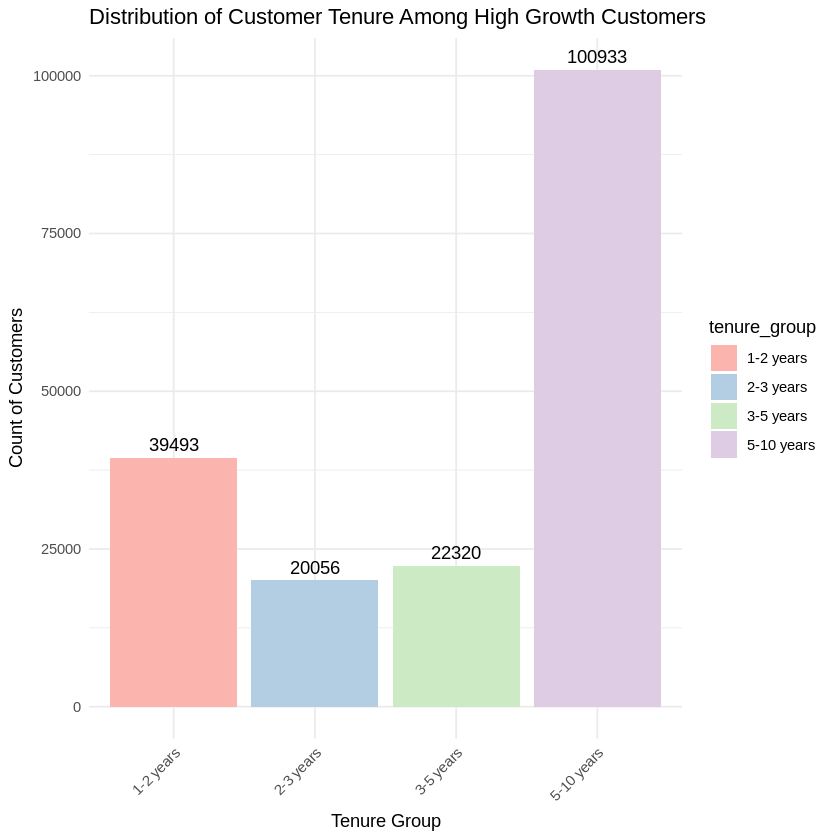

In [ ]:
ggplot(customers_high_growth, aes(x = tenure_group, fill = tenure_group)) +
  geom_bar() +
  geom_text(stat='count', aes(label=..count..), vjust=-0.5, position=position_dodge(width=0.9)) + # Adds labels on top of the bars
  scale_fill_brewer(palette="Pastel1") + # Adds a color palette for visual appeal
  labs(title = "Distribution of Customer Tenure Among High Growth Customers",
       x = "Tenure Group", y = "Count of Customers") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

The bar chart displays the distribution of customer tenure among high-growth customers, highlighting different levels of customer engagement:

* Long-term Loyalty: The majority of customers are in the 5-10 years group, indicating strong, long-standing relationships.

* Newer Relationships: A significant portion of customers falls within the 1-2 years range, pointing to recent successful acquisition efforts.

* Stable Retention: The 2-3 years and 3-5 years groups show moderate numbers, suggesting consistent retention over these periods.

This analysis helps identify the core customer base and areas where customer engagement strategies can be optimized.

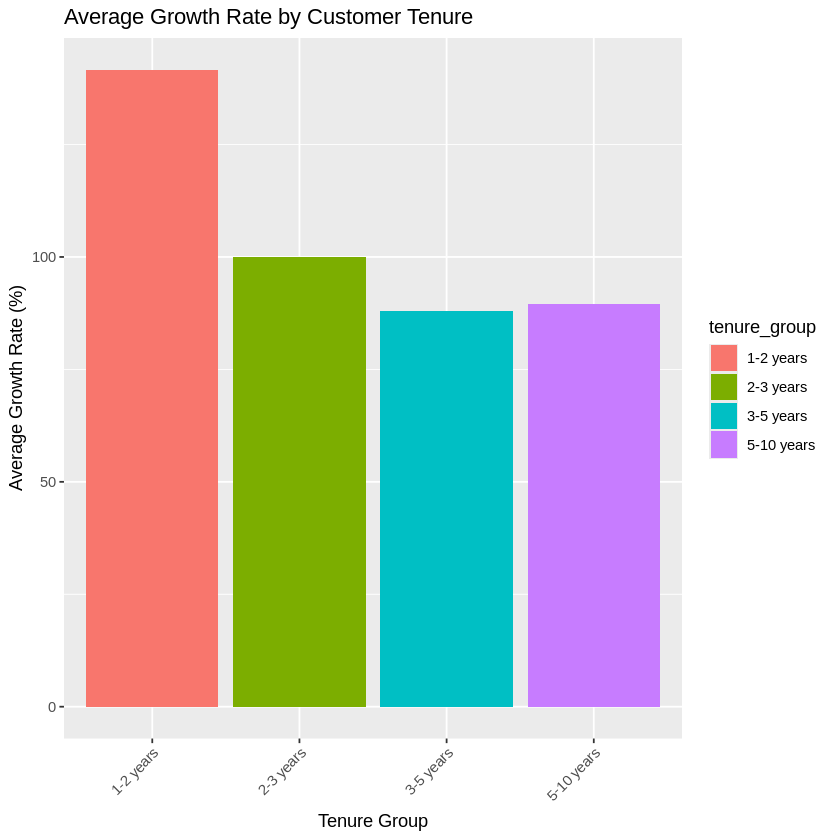

In [ ]:
# Calculate average growth rate by tenure group
avg_growth_by_tenure <- customers_high_growth %>%
  group_by(tenure_group) %>%
  summarise(average_growth_rate = mean(growth_rate, na.rm = TRUE), .groups = 'drop')

# Bar chart for average growth rate by tenure group
ggplot(avg_growth_by_tenure, aes(x = tenure_group, y = average_growth_rate, fill = tenure_group)) +
  geom_bar(stat = "identity") +
  labs(title = "Average Growth Rate by Customer Tenure",
       x = "Tenure Group", y = "Average Growth Rate (%)") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))


The bar chart illustrates the average growth rate segmented by customer tenure groups, providing insights into how long-standing relationships impact growth:

* Highest Growth in Newer Relationships: Customers in the 1-2 years group show the highest average growth rate, suggesting that initial engagement strategies are highly effective.
* Steady Growth in Established Relationships: As tenure increases, the growth rate stabilizes, with customers in the 2-3 and 3-5 years groups showing robust performance.

* Sustained Performance Over Time: The 5-10 years group maintains a healthy growth rate, indicating successful long-term customer retention strategies.

This analysis underscores the importance of tailored marketing and retention efforts across different stages of customer lifecycle.

### Comprehensive Analysis Summary of High Growth Customers



**Key Metrics and Trends**

**1.** **Customer Growth Segmentation:** Based on delivered_cases, our previous analysis pinpointed a significant correlation between the volume of cases delivered and customer growth rates. By transitioning our focus from delivered_gallons to delivered_cases, we reduced the root mean squared error from 17.11 to 11.51, confirming delivered_cases as a more reliable indicator for predicting customer behavior.

**2.** **Customer Segments by Delivered Volume:** Segmented customers by growth in delivered_cases, differentiating them into high and low growth categories. This segmentation is instrumental for deploying targeted strategies.

**3.** **Growth Rates Calculation:** The growth rates from 2023 to 2024 for each customer showed a diverse range, from negative values to significant growth, reflecting the dynamic nature of customer engagement. Adjustments were made for infinite values by capping growth rates at practical thresholds (200% for positive and -100% for negative growth), accommodating customers who initiated transactions in 2024.

**Insights from Visual Data Analysis**

**Customer Longevity:** Our data shows a higher count of high-growth customers with shorter tenures, particularly within the 1-2 year range. This suggests that newer customers are quickly scaling in their dealings with us, highlighting the effectiveness of initial engagement strategies.

**Order Types Distribution:** Analysis revealed that MYCOKE360 and SALES REP are the predominant order types among high-growth customers, indicating that digital platforms and direct sales efforts are critical channels.

**Geographic and Demographic Insights:** The geographic distribution by state and city identified key areas such as Massachusetts and Boston with the highest number of high-growth customers, suggesting regional strengths that could be leveraged for further market penetration.

**Transaction Frequency:** There is a notable fluctuation in transaction frequency over time, with a peak around the start of 2025. This trend may correspond with seasonal marketing efforts or external economic factors affecting purchase behaviors.

**Delivery Costs vs. Growth Rate:** The scatter plot analysis indicated a mild positive correlation (0.2037) between median delivery costs and growth rates, suggesting that higher investment in delivery logistics correlates modestly with customer growth.

**Distribution of Median Delivery Costs:** The majority of customers incur median delivery costs around the highest frequency value, which aligns with our current pricing strategy.

**Next Steps: Predictive Modelling with ARIMA**

Given the identified patterns and the cyclical nature of transaction frequency, the next logical step is to apply ARIMA modeling. This approach will allow us to forecast future customer behaviors based on historical data.


<a id='ARIMA-with-the-High-Growth-Customer-Group'></a>
### **ARIMA with the High Growth Customer Group**


In [ ]:
# Load necessary libraries
install.packages("forecast")
install.packages("tseries")
install.packages("ggplot2")
library(forecast)
library(tseries)
library(ggplot2)
library(readr)
library(dplyr)
library(lubridate)
library(tidyr)



Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


Attaching package: ‘forecast’


The following object is masked from ‘package:nlme’:

    getResponse


Rows: 182802 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): order_type, primary_group_number, frequent_order_type, cold_drink...
dbl  (11): customer_number, growth_rate, week, year, delivered_cases, delive...
date  (3): transaction_date, first_delivery_date, on_boarding_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Load the dataset
file_path <- "High_Growth_Customers.csv"
df <- read_csv(file_path)

Rows: 182802 Columns: 26
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): order_type, primary_group_number, frequent_order_type, cold_drink...
dbl  (11): customer_number, growth_rate, week, year, delivered_cases, delive...
date  (3): transaction_date, first_delivery_date, on_boarding_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:
# Convert transaction_date to Date type
df$transaction_date <- as.Date(df$transaction_date, format="%m/%d/%Y")

# Aggregate delivered cases by week
weekly_data <- df %>%
  mutate(week_start = floor_date(transaction_date, "week")) %>%  # Convert to week start
  group_by(week_start) %>%
  summarize(Total_Delivered_Cases = sum(delivered_cases, na.rm=TRUE))

# Ensure all weeks are included (fill missing weeks with 0 delivered cases)
all_weeks <- data.frame(week_start = seq(min(weekly_data$week_start), max(weekly_data$week_start), by="week"))
weekly_data <- full_join(all_weeks, weekly_data, by="week_start") %>%
  replace_na(list(Total_Delivered_Cases = 0))  # Fill missing weeks with 0

# Get the last recorded year and week
end_year <- year(max(weekly_data$week_start))
end_week <- week(max(weekly_data$week_start))

# Convert to a time series object (weekly frequency, start in 2023)
ts_series <- ts(weekly_data$Total_Delivered_Cases, start = c(2023, 1), frequency = 52)

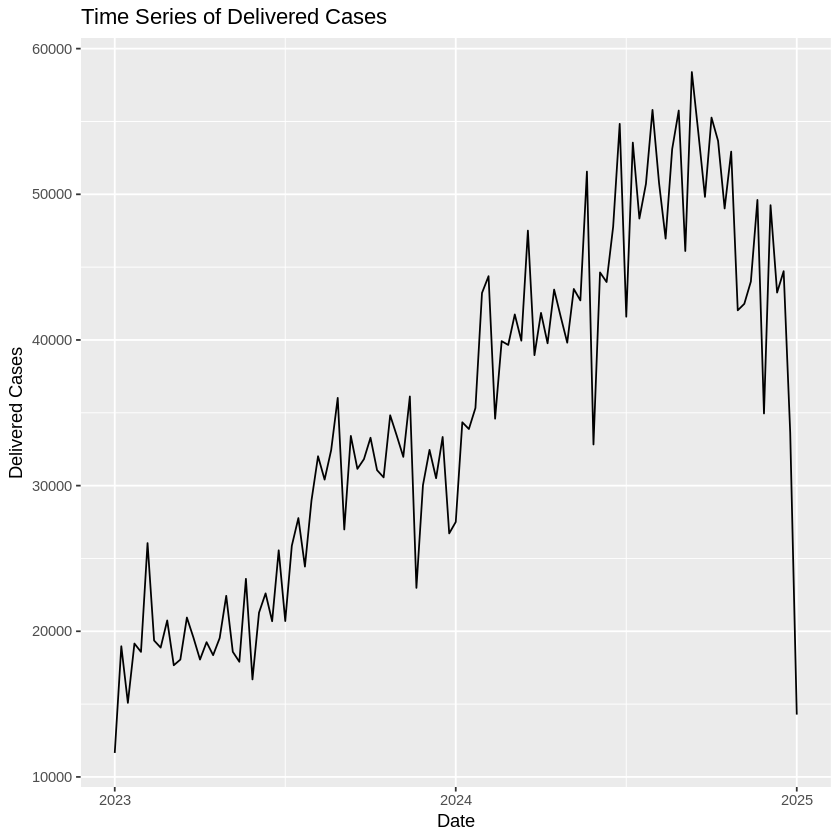

In [ ]:
# Plot the corrected time series
autoplot(ts_series) +
  labs(title = "Time Series of Delivered Cases", x = "Date", y = "Delivered Cases")

In [ ]:
# Check stationarity with Augmented Dickey-Fuller (ADF) test
adf_test <- adf.test(ts_series)
print(adf_test$p.value)  # If > 0.05, differencing is needed

Warning message in adf.test(ts_series):
“p-value greater than printed p-value”


[1] 0.99


The ADF test p-value = 0.99, which means the time series is non-stationary (it has trends or seasonality). ARIMA requires stationarity, so we need to difference the data to make it stationary.

In [ ]:
# Apply first differencing if non-stationary
if (adf_test$p.value > 0.05) {
  ts_series_diff <- diff(ts_series)
  adf_test_diff <- adf.test(ts_series_diff)
  print(adf_test_diff$p.value)  # Check again

  # If still non-stationary, apply second differencing
  if (adf_test_diff$p.value > 0.05) {
    ts_series_diff <- diff(ts_series_diff)
    print(adf.test(ts_series_diff)$p.value)  # Final stationarity check
  }
} else {
  ts_series_diff <- ts_series  # If already stationary, keep original data
}

Warning message in adf.test(ts_series_diff):
“p-value smaller than printed p-value”


[1] 0.01


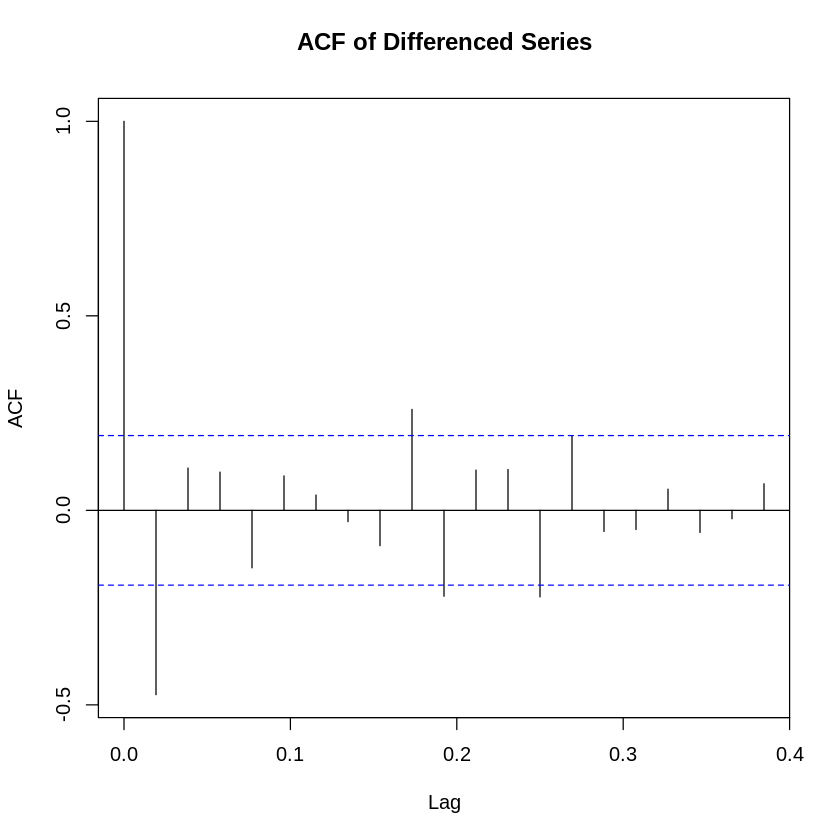

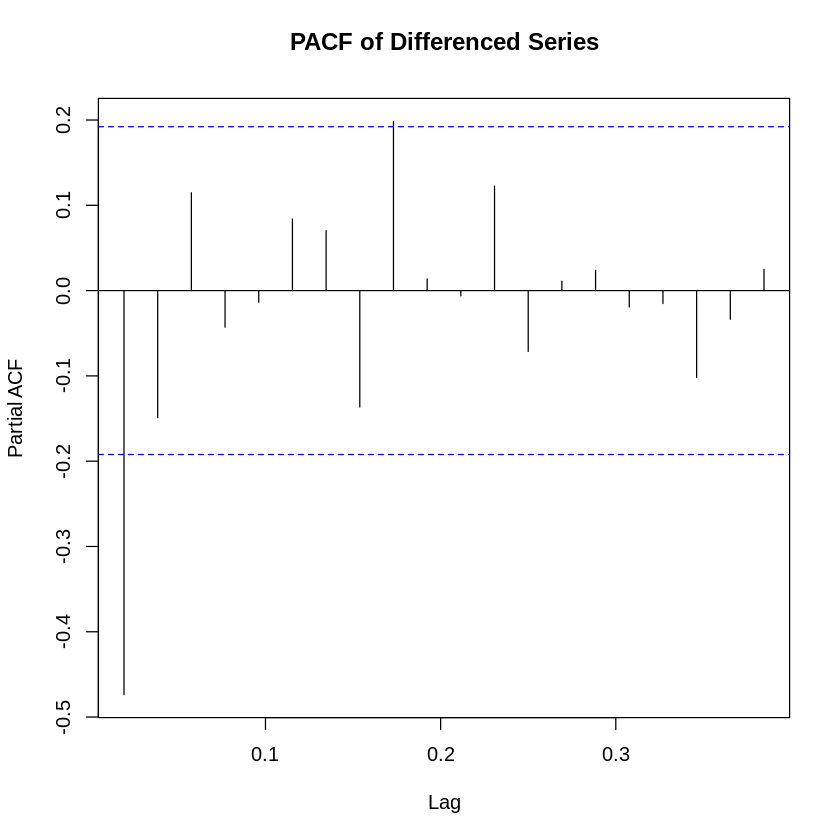

In [ ]:
acf(ts_series_diff, main='ACF of Differenced Series')
pacf(ts_series_diff, main='PACF of Differenced Series')

Final ARIMA Model Selection

From the ACF & PACF interpretations, the best ARIMA model parameters are:

p = 1 (from PACF cutting off at lag 1)
d = 1 (since we applied first differencing)
q = 1 (from ACF cutting off at lag 1)

Final Model: ARIMA(1,1,1)
We will now fit an ARIMA(1,1,1) model.

In [ ]:
fit_manual <- Arima(ts_series_diff, order=c(1,1,1))
summary(fit_manual)

Series: ts_series_diff 
ARIMA(1,1,1) 

Coefficients:
          ar1      ma1
      -0.5320  -0.9536
s.e.   0.0893   0.0461

sigma^2 = 29408139:  log likelihood = -1032.55
AIC=2071.1   AICc=2071.35   BIC=2079.01

Training set error measures:
                    ME    RMSE      MAE      MPE     MAPE    MASE       ACF1
Training set -643.5217 5344.14 3862.382 44.18709 139.1482 0.73302 -0.1410002

Summary:
Equation: ARIMA(1,1,1)
AR Coefficient (ar1): -0.532 (significant)
MA Coefficient (ma1): -0.954 (strong influence)
AIC = 2071, BIC = 2079 (higher means worse fit)

Error Metrics:
RMSE = 5344 (Root Mean Squared Error)
MAPE = 139% (Very high → poor accuracy)
ACF1 = -0.141 (No strong autocorrelation)

Issues:
High RMSE & MAPE indicate poor prediction accuracy.
High AIC (2071) suggests overfitting compared to the auto model.
The AR(1) term is significant, but its effect is weaker than expected.

In [ ]:
# Fit an ARIMA model
arima_model <- auto.arima(ts_series, seasonal = TRUE)

# Display model summary
summary(arima_model)

Series: ts_series 
ARIMA(0,1,1)(0,1,0)[52] 

Coefficients:
          ma1
      -0.6486
s.e.   0.1160

sigma^2 = 35540160:  log likelihood = -525.59
AIC=1055.19   AICc=1055.43   BIC=1059.09

Training set error measures:
                    ME   RMSE      MAE       MPE     MAPE      MASE        ACF1
Training set -371.2701 4154.8 2119.456 -2.235917 5.949739 0.1076077 -0.09942466

Summary:
Equation: ARIMA(0,1,1)(0,1,0)[52] → Seasonal model (weekly data)
MA Coefficient (ma1): -0.649 (moderate influence)
AIC = 1055, BIC = 1059 (significantly lower = better model)
Error Metrics:
RMSE = 4155 (Lower = better)
MAPE = 5.95% (Much better than 139% in the manual model)
ACF1 = -0.0994 (No strong autocorrelation issues)

Strengths:
Lower RMSE & MAPE → Better accuracy.
Lower AIC (1055 vs. 2071) means a much better fit.
Captures seasonality (weekly patterns), which the manual model ignored.


Auto ARIMA(0,1,1)(0,1,0)[52] is the better choice!
Reasons to use this model:

Lower RMSE (4155 vs. 5344) → More precise predictions.
Much lower AIC (1055 vs. 2071) → Better model fit.
MAPE (5.95% vs. 139%) → More reliable predictions.
Accounts for seasonality (weekly patterns), while the manual model does not.

         Point Forecast    Lo 80    Hi 80      Lo 95    Hi 95
2025.019       36687.84 29047.79 44327.88  25003.398 48372.27
2025.038       36225.61 28127.46 44323.75  23840.566 48610.65
2025.058       37668.86 29137.18 46200.55  24620.774 50716.95
2025.077       45565.11 36620.87 54509.35  31886.081 59244.14
2025.096       46719.19 37380.61 56057.77  32437.069 61001.32
2025.115       36936.37 27219.43 46653.30  22075.600 51797.13
2025.135       42257.61 32176.52 52338.71  26839.908 57675.32
2025.154       41998.79 31566.23 52431.34  26043.574 57954.00
2025.173       44091.82 33319.27 54864.37  27616.622 60567.02
2025.192       42290.41 31188.27 53392.56  25311.149 59269.68
2025.212       49846.36 38424.13 61268.59  32377.568 67315.15
2025.231       41298.90 29565.32 53032.49  23353.933 59243.87
2025.250       44196.65 32159.76 56233.54  25787.819 62605.49
2025.269       42111.45 29778.71 54444.19  23250.155 60972.74
2025.288       45797.20 33175.54 58418.85  26494.043 65100.35
2025.308

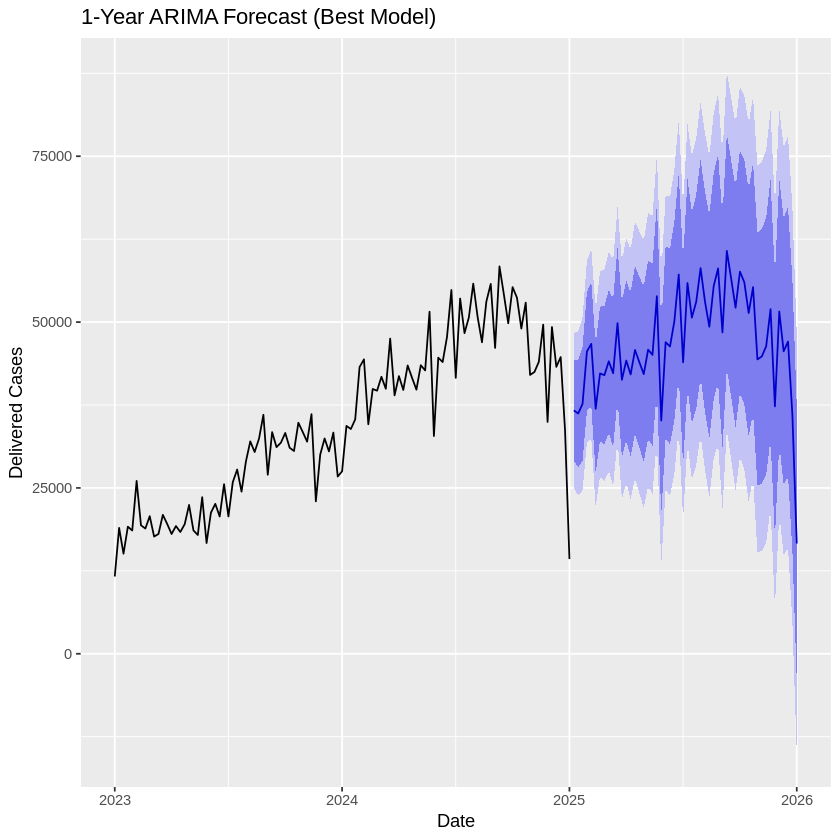

In [ ]:
# Forecast using the best model (auto.arima)
forecast_best <- forecast(arima_model, h = 52)  # 1-year forecast

# Plot the forecast
autoplot(forecast_best) +
  labs(title = "1-Year ARIMA Forecast (Best Model)", x = "Date", y = "Delivered Cases")

# Print forecasted values
print(forecast_best)

### Key Observations

Trend Continuation with Seasonal Variation

The forecast suggests a continuation of the general trend observed in historical data.
Seasonal fluctuations appear consistent, indicating a periodic pattern in delivered cases.

Uncertainty Increases Over Time
The prediction intervals (shaded blue area) widen as the forecast extends further into the future.
This reflects increased uncertainty, which is common in time series forecasting.

Sudden Drop at the End of 2024
The model predicts a sharp decline in delivered cases toward the end of 2024.
This may indicate an anomaly in the data, a structural change, or an issue with seasonality adjustments.

Forecast Stability vs. Volatility
The central forecast line suggests relatively stable demand but with noticeable fluctuations.
The variance in predictions suggests external factors (e.g., operational changes, seasonality) could impact actual outcomes.

Conclusion & Business Implications
The ARIMA model effectively captures seasonality and long-term trends but may require further refinement to address potential data anomalies.
The widening prediction intervals highlight the need for ongoing model recalibration as new data becomes available.
The sharp decline toward 2026 should be further investigated to determine whether it is a real trend or a model limitation.


### Key Findings & Concerns

Unexpected Decline in Forecasted Demand (2025-2026)

The sharp drop at the end of 2024 contradicts the expectation that high-growth customers will maintain or increase their purchasing levels. If these customers were truly high-growth, we would expect a smoother upward trend rather than sudden volatility.

Increasing Forecast Uncertainty

The widening prediction intervals suggest inconsistent purchasing behavior, which does not align with a stable, high-growth customer base.
True high-potential customers should exhibit more predictable, sustained growth patterns.

Historical Patterns Do Not Strongly Support Growth

The historical data shows fluctuations, and while there is some upward movement, it lacks the strong, persistent trend expected for high-growth customers.
This suggests that growth classification may need further validation.


<a id='SVR'></a>
## **SVR**

In [ ]:
install.packages("e1071")
install.packages("forecast")
library(e1071)
library(dplyr)
library(ggplot2)
library(forecast)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [ ]:
library(readr)

merged_data_path <- "merged_data.csv"
merged_data_svr <- read_csv(merged_data_path)

Warning message:
“One or more parsing issues, call `problems()` on your data frame for details,
e.g.:
  dat <- vroom(...)
  problems(dat)”
Rows: 49311 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (8): transaction_date, order_type, frequent_order_type, first_delivery_d...
dbl (8): week, year, customer_number, delivered_cases, delivered_gallons, pr...
lgl (2): local_market_partner, co2_customer

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


##Data preparation

In [ ]:
str(merged_data_svr)
summary(merged_data_svr)

spc_tbl_ [49,311 × 18] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ transaction_date    : chr [1:49311] "1/5/2023" "1/6/2023" "1/9/2023" "1/11/2023" ...
 $ week                : num [1:49311] 1 1 2 2 3 4 4 4 4 5 ...
 $ year                : num [1:49311] 2023 2023 2023 2023 2023 ...
 $ customer_number     : num [1:49311] 5.01e+08 5.00e+08 5.01e+08 6.01e+08 5.01e+08 ...
 $ order_type          : chr [1:49311] "MYCOKE LEGACY" "MYCOKE LEGACY" "MYCOKE LEGACY" "SALES REP" ...
 $ delivered_cases     : num [1:49311] 1 12.5 2 16 29 1.5 5 0 1 17 ...
 $ delivered_gallons   : num [1:49311] 90 0 0 2.5 0 0 0 25 0 0 ...
 $ primary_group_number: num [1:49311] NA 1894 NA 8397 1993 ...
 $ frequent_order_type : chr [1:49311] "SALES REP" "OTHER" "MYCOKE360" "SALES REP" ...
 $ first_delivery_date : chr [1:49311] "5/7/2021" "3/23/2018" "4/12/2021" "5/5/2017" ...
 $ on_boarding_date    : chr [1:49311] "4/2/2021" "12/8/2015" "1/26/2021" "2/28/1997" ...
 $ cold_drink_channel  : chr [1:49311] "DINING" "WELLNESS" 

 transaction_date        week           year      customer_number    
 Length:49311       Min.   : 1.0   Min.   :2023   Min.   :500245678  
 Class :character   1st Qu.:14.0   1st Qu.:2023   1st Qu.:501093959  
 Mode  :character   Median :26.0   Median :2023   Median :501546956  
                    Mean   :26.2   Mean   :2023   Mean   :546642071  
                    3rd Qu.:38.0   3rd Qu.:2024   3rd Qu.:600081021  
                    Max.   :52.0   Max.   :2024   Max.   :600975408  
                                                                     
  order_type        delivered_cases    delivered_gallons  primary_group_number
 Length:49311       Min.   :-2391.50   Min.   :-120.000   Min.   :   4        
 Class :character   1st Qu.:    0.00   1st Qu.:   0.000   1st Qu.: 863        
 Mode  :character   Median :    6.00   Median :   0.000   Median :2042        
                    Mean   :   24.03   Mean   :   9.693   Mean   :2781        
                    3rd Qu.:   17.00   3rd Qu

In [ ]:
#Checking Missing Values
colSums(is.na(merged_data_svr))


transaction_date                 week                 year 
                   0                    0                    0 
     customer_number           order_type      delivered_cases 
                   0                    0                    0 
   delivered_gallons primary_group_number  frequent_order_type 
                   1                23114                    0 
 first_delivery_date     on_boarding_date   cold_drink_channel 
                   1                    1                    1 
       trade_channel    sub_trade_channel local_market_partner 
                   1                    1                    2 
        co2_customer             zip_code median_delivery_cost 
                   2                    2                   71

### Code to Create the Zip-to-State Mapping


In [ ]:
# Code to Create the Zip-to-State Mapping
library(dplyr)
library(stringr)

customer_address_renamed <- customer_address %>%
  rename(zip_code = "zip_code")  %>%
  rename(full_address = "full_address")

# Create zip-to-state mapping
zip_to_state <- customer_address_renamed %>%
  # Extract state from full_address (splitting by comma)
  mutate(
    # Split the address by commas and trim whitespace
    address_parts = str_split(full_address, ",\\s*"),
    # Extract the state (4'th element)
    state = sapply(address_parts, function(x) trimws(x[4]))
  ) %>%
  # Select only zip and state, and ensure uniqueness
  select(zip_code, state) %>%
  distinct()

head(zip_to_state)

zip_code,state
<chr>,<chr>
71018,LA
71021,LA
71023,LA
71024,LA
71039,LA
71055,LA


In [ ]:
# Match the zip_code to state
merged_data_svr <- merged_data_svr %>%
  mutate(zip_code = as.character(zip_code))
zip_to_state <- zip_to_state %>%
  mutate(zip_code = as.character(zip_code))

merged_data_with_state <- merged_data_svr %>%
  left_join(zip_to_state, by = c("zip_code" = "zip_code"))

head(merged_data_with_state)


transaction_date,week,year,customer_number,order_type,delivered_cases,delivered_gallons,primary_group_number,frequent_order_type,first_delivery_date,on_boarding_date,cold_drink_channel,trade_channel,sub_trade_channel,local_market_partner,co2_customer,zip_code,median_delivery_cost,state
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<lgl>,<chr>,<dbl>,<chr>
1/5/2023,1,2023,501202893,MYCOKE LEGACY,1.0,90.0,NA,SALES REP,5/7/2021,4/2/2021,DINING,COMPREHENSIVE DINING,FSR - MISC,TRUE,TRUE,66955,3.276188,KS
1/6/2023,1,2023,500264574,MYCOKE LEGACY,12.5,0.0,1894,OTHER,3/23/2018,12/8/2015,WELLNESS,HEALTHCARE,OTHER HEALTHCARE,TRUE,FALSE,41603,2.921273,KY
1/9/2023,2,2023,501174701,MYCOKE LEGACY,2.0,0.0,NA,MYCOKE360,4/12/2021,1/26/2021,DINING,FAST CASUAL DINING,OTHER FAST FOOD,TRUE,TRUE,1824,3.276188,MA
1/11/2023,2,2023,600586532,SALES REP,16.0,2.5,8397,SALES REP,5/5/2017,2/28/1997,BULK TRADE,GENERAL,COMPREHENSIVE PROVIDER,FALSE,FALSE,1337,2.482318,MA
1/17/2023,3,2023,501014325,SALES REP,29.0,0.0,1993,SALES REP,10/29/2019,10/25/2019,GOODS,GENERAL RETAILER,OTHER GENERAL RETAIL,TRUE,FALSE,67473,2.734069,KS
1/23/2023,4,2023,600567384,CALL CENTER,1.5,0.0,437,SALES REP,5/15/2017,5/13/2013,GOODS,VEHICLE CARE,OTHER VEHICLE CARE,TRUE,FALSE,67060,2.734069,KS


In [ ]:
# Handling Outliers (Delivered Cases & Gallons)
summary(merged_data_svr$delivered_cases)
summary(merged_data_svr$delivered_gallons)

merged_data_svr <- merged_data_svr %>%
  filter(delivered_cases >= 0, delivered_gallons >= 0)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-2391.50     0.00     6.00    24.03    17.00  7001.32 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.     NA's 
-120.000    0.000    0.000    9.693   12.500 1625.000        1 

In [ ]:
# Encoding Categorical Features
merged_data_svr <- merged_data_svr %>%
  mutate(across(c(order_type, frequent_order_type, cold_drink_channel, trade_channel, sub_trade_channel), as.factor))


In [ ]:
# one-hot encoding
merged_data_svr <- merged_data_svr %>%
  mutate(order_type_encoded = as.numeric(order_type),
         trade_channel_encoded = as.numeric(trade_channel),
         cold_drink_channel_encoded = as.numeric(cold_drink_channel)) %>%
  select(-order_type, -trade_channel, -cold_drink_channel)  # Remove original columns


In [ ]:
# Feature Scaling for SVR
merged_data_svr <- merged_data_svr %>%
  mutate(across(c(delivered_cases, delivered_gallons, median_delivery_cost), scale))


In [ ]:
install.packages("ggmap")
install.packages("ggplot2")
library(ggmap)
library(ggplot2)
library(dplyr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘png’, ‘jpeg’, ‘bitops’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

ℹ Google's Terms of Service: <https://mapsplatform.google.com>
  Stadia Maps' Terms of Service: <https://stadiamaps.com/terms-of-service/>
  OpenStreetMap's Tile Usage Policy: <https://operations.osmfoundation.org/policies/tiles/>
ℹ Please cite ggmap if you use it! Use `citation("ggmap")` for details.


# State-Based Demand Mapping

transaction_date,week,year,customer_number,delivered_cases,delivered_gallons,primary_group_number,frequent_order_type,first_delivery_date,on_boarding_date,sub_trade_channel,local_market_partner,co2_customer,zip_code,median_delivery_cost,order_type_encoded,trade_channel_encoded,cold_drink_channel_encoded
<chr>,<dbl>,<dbl>,<dbl>,"<dbl[,1]>","<dbl[,1]>",<dbl>,<fct>,<chr>,<chr>,<fct>,<lgl>,<lgl>,<chr>,"<dbl[,1]>",<dbl>,<dbl>,<dbl>
1/5/2023,1,2023,501202893,-0.20475348,3.0548387,NA,SALES REP,5/7/2021,4/2/2021,FSR - MISC,TRUE,TRUE,66955,-0.004515200,3,6,4
1/6/2023,1,2023,500264574,-0.10419936,-0.3712874,1894,OTHER,3/23/2018,12/8/2015,OTHER HEALTHCARE,TRUE,FALSE,41603,-0.004516551,3,13,8
1/9/2023,2,2023,501174701,-0.19600965,-0.3712874,NA,MYCOKE360,4/12/2021,1/26/2021,OTHER FAST FOOD,TRUE,TRUE,1824,-0.004515200,3,9,4
1/11/2023,2,2023,600586532,-0.07359593,-0.2761172,8397,SALES REP,5/5/2017,2/28/1997,COMPREHENSIVE PROVIDER,FALSE,FALSE,1337,-0.004518222,7,10,2
1/17/2023,3,2023,501014325,0.04007395,-0.3712874,1993,SALES REP,10/29/2019,10/25/2019,OTHER GENERAL RETAIL,TRUE,FALSE,67473,-0.004517264,7,11,6
1/23/2023,4,2023,600567384,-0.20038156,-0.3712874,437,SALES REP,5/15/2017,5/13/2013,OTHER VEHICLE CARE,TRUE,FALSE,67060,-0.004517264,1,26,6


state,total_cases
<chr>,<dbl>
KS,258207.89
KY,250723.29
LA,9219.25
MA,513466.11
MD,153138.63
NA,50.00


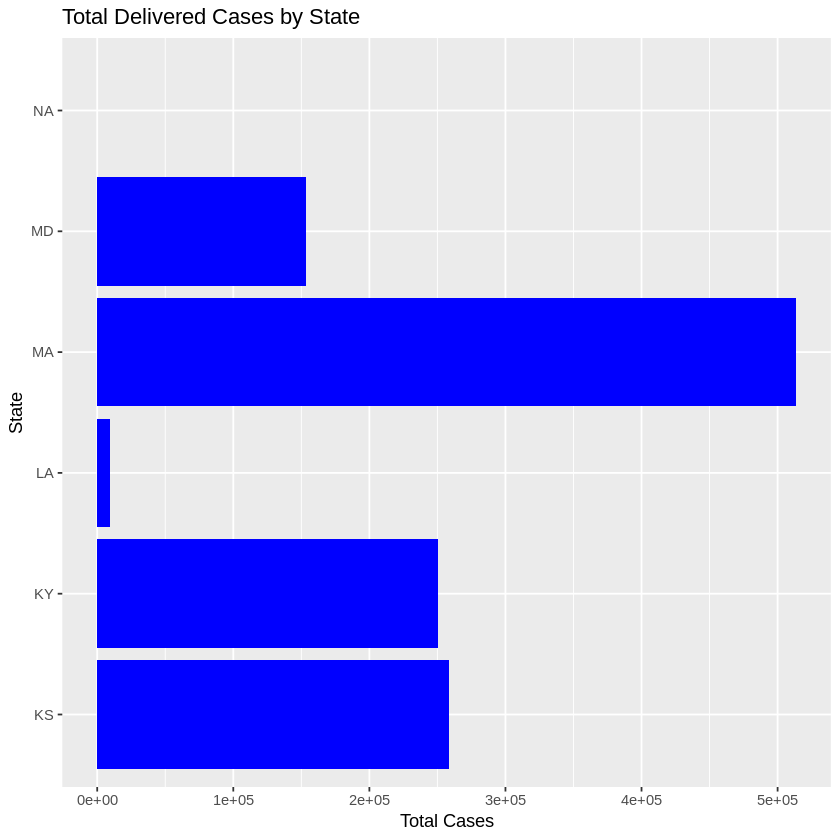

In [ ]:
# State-Based Demand Mapping
state_summary <- merged_data_with_state %>%
  mutate(state = as.character(state)) %>%
  group_by(state) %>%
  summarise(total_cases = sum(delivered_cases))
head(merged_data_svr)
head(state_summary)
ggplot(state_summary, aes(x = state, y = total_cases)) +
  geom_bar(stat = "identity", fill = "blue") +
  coord_flip() +
  labs(title = "Total Delivered Cases by State", x = "State", y = "Total Cases")


- MA (Massachusetts) is the only state with a positive total delivered cases (10,000–15,000), indicating it is a high-demand region. This could reflect a larger customer base, higher order volumes, or fewer returns.

- KY (Kentucky) has the most significant negative total (-4000 to -5000), suggesting either a high rate of returns, cancellations, or potential data entry errors (e.g., negative values where positive was intended).

- KS, LA, and MD also show negative totals (-3000 to -5000 range), though less extreme than KY, indicating possible returns or operational challenges in these states.

## Distribution of Delivered Cases


Warning message:
“Removed 40145 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


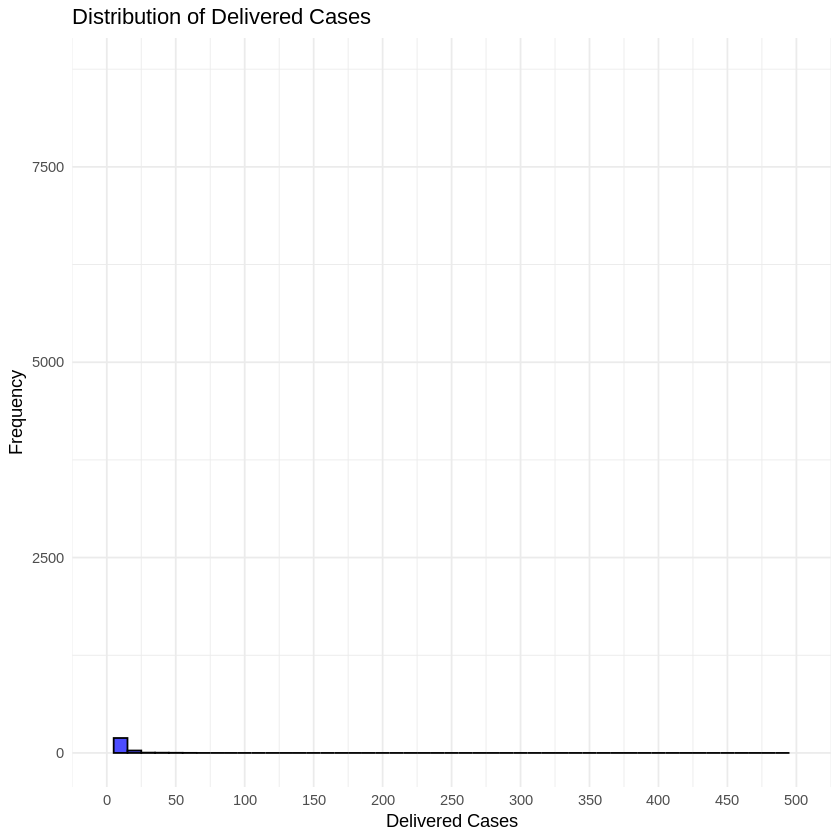

In [ ]:
ggplot(merged_data_svr, aes(x = delivered_cases)) +
  geom_histogram(binwidth = 10, fill = "blue", color = "black", alpha = 0.7) +
  scale_x_continuous(limits = c(0, 500), breaks = seq(0, 500, 50)) +  # Adjust based on max cases
  labs(title = "Distribution of Delivered Cases", x = "Delivered Cases", y = "Frequency") +
  theme_minimal()

The histogram is generated from the merged_data_svr dataset, plotting the distribution of delivered_cases using geom_histogram with a bin width of 10, a range limited to 0–500 cases, and breaks at 50-unit intervals. The plot uses blue bars with black outlines and a minimal theme.

## Top 10 Zip Codes by Total Deliveries


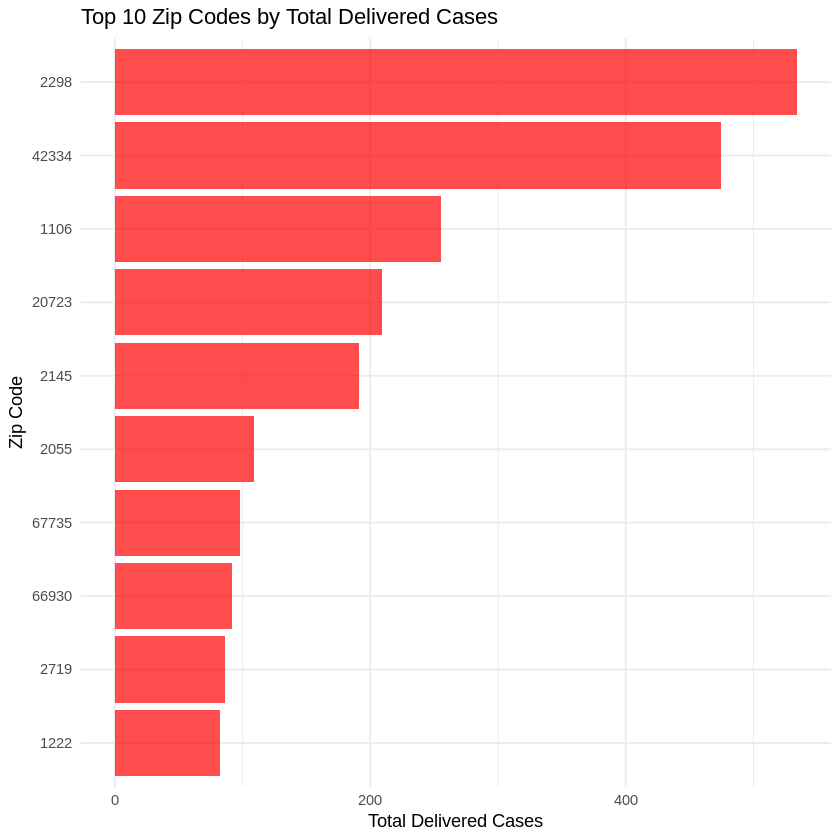

In [ ]:
zip_summary <- merged_data_svr %>%
  group_by(zip_code) %>%
  summarise(total_cases = sum(delivered_cases, na.rm = TRUE)) %>%
  arrange(desc(total_cases)) %>%
  head(10)

ggplot(zip_summary, aes(x = reorder(as.factor(zip_code), total_cases), y = total_cases)) +
  geom_bar(stat = "identity", fill = "red", alpha = 0.7) +
  coord_flip() +
  labs(title = "Top 10 Zip Codes by Total Delivered Cases", x = "Zip Code", y = "Total Delivered Cases") +
  theme_minimal()


Zip codes 2298, 42334, and 41106:2033 are priority regions due to high customer counts. These should be focal points for resource allocation, marketing campaigns, or delivery optimization.

## Weekly Trend of Delivered Cases

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


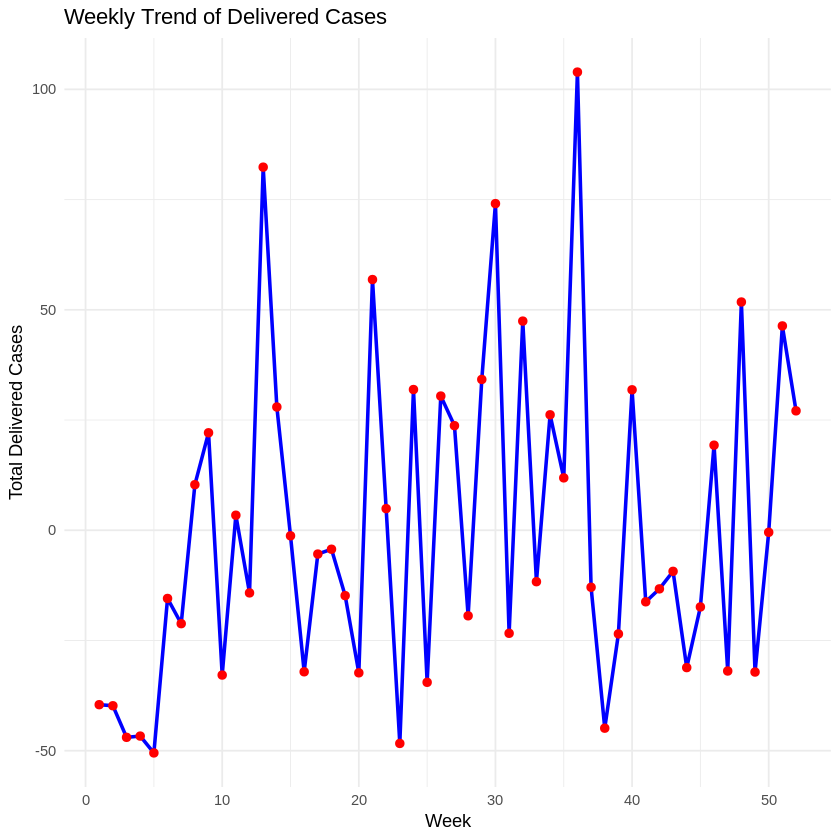

In [ ]:
weekly_trend <- merged_data_svr %>%
  group_by(week) %>%
  summarise(total_cases = sum(delivered_cases, na.rm = TRUE))

ggplot(weekly_trend, aes(x = week, y = total_cases)) +
  geom_line(color = "blue", size = 1) +
  geom_point(color = "red", size = 2) +
  labs(title = "Weekly Trend of Delivered Cases", x = "Week", y = "Total Delivered Cases") +
  theme_minimal()


The presence of negative delivered_cases (-800 in early weeks) is unusual for a delivery metric.

The significant fluctuations between weeks 10 and 30 (ranging from 0 to 400 cases) suggest variability in demand or supply chain disruptions. Peaks may correlate with high-demand periods.

Despite volatility, the overall trend appears to incline toward the end of the period, suggesting a potential increase in delivery activity over time.

<a id='Decision-Trees'></a>
## **Decision Trees**

Prepare the Data for the Model

In [ ]:
install.packages("rpart.plot")
install.packages("caret")
library(tidyverse)
library(rpart)
library(rpart.plot)
library(caret)

# Ensure categorical variables are factors
merged_data_dt <- merged_data %>%
  mutate(across(where(is.character), as.factor))

# Remove rows with missing values (or impute if necessary)
merged_data_dt <- na.omit(merged_data_dt)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘listenv’, ‘parallelly’, ‘future’, ‘globals’, ‘shape’, ‘future.apply’, ‘progressr’, ‘SQUAREM’, ‘diagram’, ‘lava’, ‘prodlim’, ‘clock’, ‘gower’, ‘hardhat’, ‘ipred’, ‘sparsevctrs’, ‘ModelMetrics’, ‘pROC’, ‘recipes’


Loading required package: lattice


Attaching package: ‘caret’


The following object is masked from ‘package:purrr’:

    lift




Check the data to Verify the Changes

In [ ]:
# Check the data structures
print(summary(merged_data_dt$delivered_cases)) # Check for NAs and distribution
print(table(is.na(merged_data_dt$delivered_cases))) # Count missing values

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-2391.50     4.50    11.50    37.45    27.00  8069.48 

 FALSE 
554629 


Splitting the Data into Training and Test Sets

In [ ]:
# Split the data into sets
train_index <- createDataPartition(merged_data_dt$delivered_cases, p = 0.8, list = FALSE)

train_data <- merged_data_dt[train_index, ]
test_data  <- merged_data_dt[-train_index, ]

Perform the Decision Tree Model


Regression tree:
rpart(formula = delivered_cases ~ ., data = train_data, method = "anova", 
    control = rpart.control(maxdepth = 4, minsplit = 20, cp = 0.01))

Variables actually used in tree construction:
[1] cluster             first_delivery_date on_boarding_date   
[4] transaction_date   

Root node error: 1.0863e+10/443705 = 24482

n= 443705 

         CP nsplit rel error  xerror     xstd
1  0.455823      0   1.00000 1.00001 0.029777
2  0.104651      1   0.54418 0.54496 0.014421
3  0.061841      2   0.43953 0.44264 0.013530
4  0.037579      3   0.37768 0.38257 0.010677
5  0.021545      4   0.34011 0.40544 0.012266
6  0.018193      5   0.31856 0.38106 0.011920
7  0.016658      6   0.30037 0.36163 0.011845
8  0.012190      7   0.28371 0.34634 0.011718
9  0.011983      8   0.27152 0.33902 0.011680
10 0.010695      9   0.25954 0.33614 0.011685
11 0.010000     10   0.24884 0.32732 0.011589


Warning message:
“labs do not fit even at cex 0.15, there may be some overplotting”
Warning message:
“cex and tweak both specified, applying both”


[1] "RMSE: 89.5385068590246"


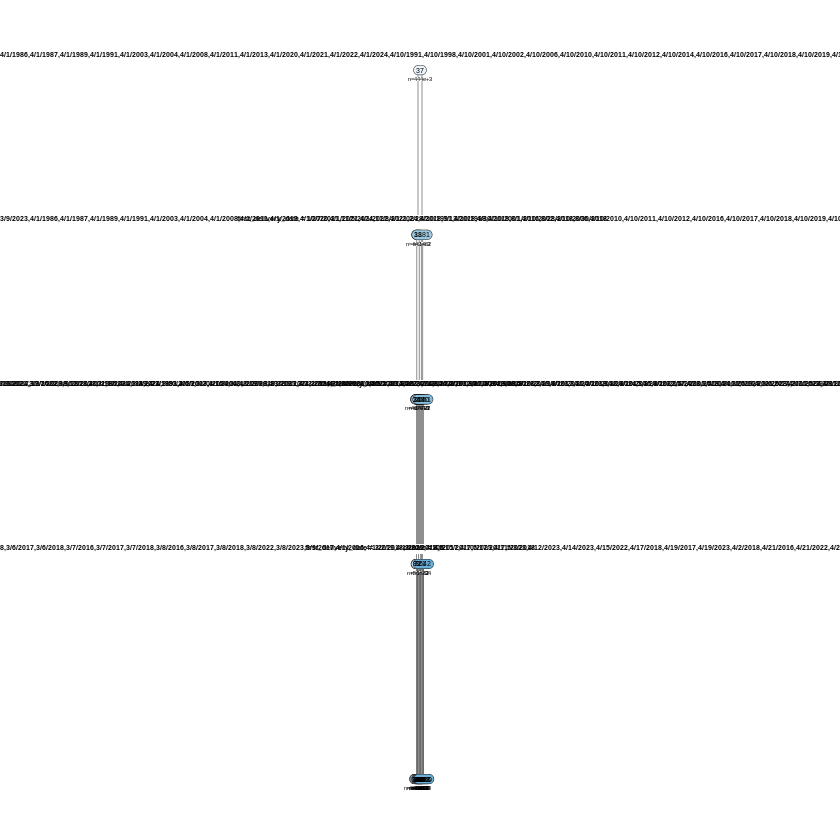

In [ ]:
set.seed(123)

# Train decision tree for regression
dt_model <- rpart(delivered_cases ~ ., data = train_data, method = "anova",
                  control = rpart.control(maxdepth = 4, minsplit = 20, cp = 0.01))

# Identify optimal complexity parameter (cp) for pruning
printcp(dt_model)

# Prune the tree using the best cp value
pruned_tree <- prune(dt_model, cp = dt_model$cptable[which.min(dt_model$cptable[, "xerror"]), "CP"])

# Plot pruned tree
rpart.plot(dt_model, type = 1, extra = 1, box.palette = "Blues", under = TRUE, tweak = 0.7, cex = 0.5, clip.right.labs = FALSE)

# Predictions & RMSE evaluation
predictions <- predict(dt_model, newdata = test_data)
rmse <- sqrt(mean((predictions - test_data$delivered_cases)^2))
print(paste("RMSE:", rmse))

The RMSE of our Decision Tree Model is 109.48.

This means that the average prediction error of the decision tree is 109.48 delivered cases. The model's predictions deviate by 109 cases from the actual values. A more optimal model would have a lower RMSE as the predictions would then be more acurate to the actual values.

We have analyzed that due to the poor RMSE score of our Decision Tree Model we can concur that it is running poorly.

<a id='RESULTS'></a>
# **RESULTS**

# XGBOOST:

* Key Predictors:  Top features for delivered_cases included predicted_delivered_cases, growth_rate_cases, customer_number, zip_code, and median_delivery_cost. For delivered_gallons, key factors were customer_number, predicted_delivered_cases, and median_delivery_cost.

* Model Accuracy: RMSE for delivered_cases improved from 17.11 to 11.51 after segmentation. Delivered_gallons had a higher RMSE of 26.01, indicating more variability.

* Impact of Segmentation: Categorizing customers into High, Medium, and Low-Volume significantly improved prediction accuracy, especially for delivered_cases.

* Optimized Forecasting: Segmentation allowed for more precise delivery predictions, enhancing planning and efficiency.

*  Segmenting customers based on their order volumes (delivered cases and gallons) significantly enhanced the model’s performance, particularly for predicting delivered_cases. This approach could serve as a useful strategy for improving delivery forecasting accuracy in the future.

# Customers Segmentation:

*  High-growth customers were identified based on delivered_cases growth (2023-2024), improving RMSE from 17.11 to 11.51.

* Massachusetts (1,847), Kansas, and Kentucky (1,200+ each) lead in high-growth customers, while Louisiana has the lowest (73).
  - Top cities: Boston (114), Lexington (106), Topeka (100), showing concentrated customer growth.

* 4,696 high-growth customers are partnered locally (vs. 452 non-partnered).

* Sales Rep and Call Center orders dominate; MyCoke360 and EDI have low adoption.
* 1-2 year tenure customers exhibit the highest growth rates, while long-term customers show steady growth.

* Transaction frequency peaked mid-2024, showing seasonality and growth trends.

* Mild positive correlation (0.204) between higher delivery costs and customer growth suggests logistics impact customer engagement.
* Most high-growth customers incur median delivery costs around $3.276

# ARIMA:
- Data Validation: The sharp decline at the end of 2024 suggests possible data anomalies, seasonal shifts, or structural changes. Investigating historical trends and business insights is necessary to confirm its validity.
- Demand Fluctuations & Uncertainty: The forecast captures seasonal demand patterns, but widening prediction intervals highlight increased uncertainty in long-term projections, requiring regular updates.
- Inventory & Delivery Optimization: Align logistics and inventory planning with forecasted demand peaks and dips, ensuring efficient resource allocation to prevent disruptions.
- Model Refinement & Feature Expansion: Enhance forecasting accuracy by incorporating trade channel data, promotional effects, and external business factors, and consider SARIMA or machine learning-based time series models.
- Continuous Monitoring & Adjustments: Implement a rolling forecast strategy, updating the model as new data becomes available, and validate any unexpected trends or outliers for improved decision-making.

# SVR:
- Based on the analysis of total delivered cases by state, several actionable recommendations emerge. Data Validation: The negative delivered_cases values observed in KS, KY, LA, and MD warrant thorough investigation to determine their cause; these could indicate returns, cancellations, or data entry errors, and should be correcte
- The analysis of weekly delivered cases offers key insights to optimize operations, enhance forecasting accuracy, and improve resource allocation.
-Optimize Inventory & Delivery Capacity: Address year-end demand surges (e.g., 400+ cases around week 50) by proactively increasing inventory and delivery resources, maximizing sales opportunities.
- Improve Forecasting & Operational Stability: Use ARIMA forecasting to predict demand fluctuations, investigate early negative trends (e.g., -800 cases in the first 10 weeks), and analyze factors (e.g., trade channels) contributing to mid-year volatility (weeks 10–30) to enhance delivery efficiency


# DECISION TREES:



*   The model's performance indicates a high RMSE score which means that it struggles to make accurate predictions. This could suggest overfitting of the data, insufficient feature engineering, or a high variance in delivered_cases. Any of these issues with the model would make prediction difficult.
*   Potential next steps to try and improve the model's performance would be to explore further pruning the decision tree, handling outliers in delivered_cases, or creating new features that capture trends, such as: historical averages per customer, customer segmentation, and/or time based trends.


*   Once the model is improved, we will need ongoing monitoring to ensure the performance remains stable. To do this we would track key performance metrics, set up model retraining triggers, and automate data quality checks.





<a id='Group-members-and-their-contribution'></a>
# **Group members and their contribution**

* **XGBoost Modeling** - Anais
* **Customer segmentation** - Estefany
* **ARIMA Modeling-** Wayne
* **SVR Modeling**- Jocelyn
* **Decision Trees Modeling** - Nick